# Set Attention vs Explicit Graph Structure for Ωm Inference
### DeepSets, Set Transformer, Static GCN, and the thesis-wide model benchmark
**Notebook 17 · CAMELS-SIMBA · saved-artifact analysis**

What representation most effectively extracts Ωm information from a halo catalogue? This notebook examines learned set interactions, explicit periodic neighborhoods, prediction compression, and model capacity before placing the controlled result in the complete thesis benchmark.

The experiment is closed. Every numerical result below is derived from saved predictions and checked against frozen records. No model is constructed or loaded; no training, inference, dataset construction, network access, or post-test selection occurs.

# 1. Research Question and Motivation
DeepSets tests whether independent halo encoding followed by invariant pooling is sufficient. Set Transformer adds contextual halo-to-halo interactions through induced attention without constructing edges. Static GCN supplies explicit periodic local neighborhoods and message passing. This representation ladder tests whether generic set attention recovers the predictive advantage of graph structure.

**Q1:** Does attention improve DeepSets? **Q2:** Does it close the Static GCN gap? **Q3:** Is additional parameter count sufficient? **Q4:** How do errors and target-range compression differ? **Q5:** How do these results fit the complete thesis benchmark?

> Seed 42 is used as the canonical visualization seed by preregistered convention; all quantitative conclusions use all three seeds.

Seed-specific test sets can overlap. We never pool their predictions into 603 independent observations. Means and sample SDs summarize three seed-level values; they are not confidence intervals.

# 2. Reproducibility and Artifact Preflight
The final result freeze is the source of the exact run list. The registry corroborates completion and parameter metadata; it is not searched for the best test score. The unchanged final-selection file retains its historical DeepSets Top1000 headline, while this notebook uses the explicitly frozen **Top1500 controlled comparison**.

Checkpoints are read only as bytes for SHA256 verification, never deserialized. Dataset identity is established by matching frozen configuration and manifest hashes; the large dataset is neither required nor opened for this analysis.

In [1]:
from pathlib import Path
import hashlib, json, subprocess, sys, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Markdown, HTML
from PIL import Image

def discover_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'reports/experiment_registry').is_dir():
            return candidate
    raise RuntimeError('Open this notebook inside a checkout containing reports/experiment_registry.')
ROOT = discover_root()
REG = ROOT / 'reports/experiment_registry'
OUT = ROOT / 'notebooks/visualization/outputs/17_u1000_set_transformer_vs_graph_structure_analysis'
OUT.mkdir(parents=True, exist_ok=True)
SEEDS = [42, 123, 2025]
CANONICAL_SEED = 42
DDOF = 1
TOL = 1e-10
CONTROLLED = ['DeepSets', 'Set Transformer', 'Static GCN']
EXPECTED_MODELS = ['Mean baseline', 'Ridge', 'Random Forest', 'Gradient Boosting', 'Summary MLP',
                   *CONTROLLED, 'PNA', 'EvolveGCN-H', 'EvolveGCN-O', 'GCN-GRU', 'GCN Temporal Transformer']
COLORS = dict(zip(CONTROLLED, ['#4477AA', '#AA6677', '#228877']))
MARKERS = {42: 'o', 123: '^', 2025: 's'}
assert CANONICAL_SEED == 42 and DDOF == 1
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 240, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'semibold', 'axes.labelsize': 11,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'text.color': '#23313D', 'axes.labelcolor': '#23313D'})
SOURCES = {}
GENERATED = []
def source(path):
    p = Path(path)
    p = (ROOT / p).resolve() if not p.is_absolute() else p.resolve()
    assert p.is_relative_to(ROOT) and p.is_file() and p.stat().st_size > 0, p
    key = str(p.relative_to(ROOT))
    if key not in SOURCES:
        SOURCES[key] = hashlib.sha256(p.read_bytes()).hexdigest()
    return p

def read_json(path): return json.loads(source(path).read_text())
def read_csv(path): return pd.read_csv(source(path), float_precision='round_trip')
def sha(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def git(*args):
    return subprocess.check_output(['git', *args], cwd=ROOT, text=True).strip()
def table(frame, name, show=True):
    assert np.isfinite(frame.select_dtypes(include='number').to_numpy(dtype=float)).all(), name
    p = OUT / name
    frame.to_csv(p, index=False)
    GENERATED.append(p)
    if show:
        display(frame.style.hide(axis='index').format(precision=6).set_properties(**{'text-align':'left'}))
    return frame

def savefig(fig, name):
    for ext in ['png', 'pdf']:
        p = OUT / f'{name}.{ext}'
        fig.savefig(p, dpi=240, bbox_inches='tight', facecolor='white')
        GENERATED.append(p)
    plt.show()
    plt.close(fig)

def caption(question, observation, interpretation, limitation):
    display(Markdown(f'**Question.** {question}\n\n**Observation.** {observation}\n\n'
                     f'**Interpretation.** {interpretation}\n\n**Limitation.** {limitation}'))

def pm(mean, sd, digits=6): return f'{mean:.{digits}f} ± {sd:.{digits}f}'
HEAD = git('rev-parse', 'HEAD')
CREATION_HEAD = '5e5d0b5c2c1de0a44efb88dd621edf971d5fae78'
FREEZE_PATH = 'reports/experiment_registry/u1000_top1500_set_transformer_final_result_freeze.json'
freeze = read_json(FREEZE_PATH)
assert freeze['status'] == 'finalized' and freeze['seeds'] == SEEDS
for commit in ['ff6b88f465bd0291980713fb7c595e745423839c', '9b515aa70d785f691ccfa2f0ec4e7833875a4359']:
    subprocess.run(['git', 'merge-base', '--is-ancestor', commit, HEAD], cwd=ROOT, check=True)
PROTOCOL_HASH = 'a344737fcc06197d0ecde0fc3f7bc37980bbff665b5bb0022eb726c933c4e051'
assert sha(source(freeze['protocol_freeze_path'])) == freeze['protocol_freeze_sha256'] == PROTOCOL_HASH
provenance = source('reports/reproducibility/notebook17_set_transformer_final_provenance.md').read_text()
registry = read_csv('reports/experiment_registry/master_experiment_registry.csv')
source('reports/experiment_registry/master_experiment_registry.md')
selection = read_csv(freeze['final_selection_policy']['path'])
assert sha(source(freeze['final_selection_policy']['path'])) == freeze['final_selection_policy']['sha256']
protected_manifest = read_csv('reports/reproducibility/notebook17_set_transformer_final_artifact_manifest.csv')
control_manifest = read_csv('reports/reproducibility/notebook17_control_artifact_manifest.csv')
for manifest in [protected_manifest, control_manifest]:
    assert manifest.path.is_unique
    for row in manifest.itertuples():
        p = source(row.path)
        assert p.stat().st_size == row.size_bytes and sha(p) == row.sha256, row.path
# Preserve all existing visualization notebooks as an additional run-local guard.
for p in (ROOT / 'notebooks/visualization').glob('*.ipynb'):
    if p.name[:2].isdigit() and 1 <= int(p.name[:2]) <= 16: source(p)
preflight = pd.DataFrame([
    ['Repository root', str(ROOT)], ['Execution HEAD', HEAD], ['Creation HEAD', CREATION_HEAD],
    ['Result freeze', FREEZE_PATH], ['Protocol SHA256', PROTOCOL_HASH], ['Seeds', str(SEEDS)],
    ['Final manifest entries verified', str(len(protected_manifest))],
    ['Control manifest entries verified', str(len(control_manifest))],
    ['Runtime', f'Python {platform.python_version()}; NumPy {np.__version__}; pandas {pd.__version__}; Matplotlib {matplotlib.__version__}'],
], columns=['Check', 'Verified value'])
display(preflight.style.hide(axis='index'))
print('PASS — ancestry, protocol, final selection and all frozen artifact hashes.')

Check,Verified value
Repository root,/home/ml/thesis-camels
Execution HEAD,5e5d0b5c2c1de0a44efb88dd621edf971d5fae78
Creation HEAD,5e5d0b5c2c1de0a44efb88dd621edf971d5fae78
Result freeze,reports/experiment_registry/u1000_top1500_set_transformer_final_result_freeze.json
Protocol SHA256,a344737fcc06197d0ecde0fc3f7bc37980bbff665b5bb0022eb726c933c4e051
Seeds,"[42, 123, 2025]"
Final manifest entries verified,296
Control manifest entries verified,42
Runtime,Python 3.10.12; NumPy 2.2.6; pandas 2.3.3; Matplotlib 3.10.9


PASS — ancestry, protocol, final selection and all frozen artifact hashes.


The closure provenance documents two reporting details: the control manifest has committed LF line endings (its frozen CRLF form is reproducible in memory), and the registry parser received a reporting-only correction after the implementation commit. We verify the actual referenced artifact hashes and accept a descendant HEAD. Retained test-attempt markers are expected: finalized metadata must explicitly say `evaluated_once`.

MAE is the reporting and configuration-comparison metric. Saved neural checkpoints were chosen by minimum **validation MSE**, as recorded in their run configurations; this notebook does not choose epochs again.

# 3. Controlled Experimental Design
All three models receive the same raw final-snapshot halos and Ωm target, with identical seed-specific partitions. Their interaction mechanism and parameter count differ. The table describes the frozen experiment, not a claim of causal isolation.

In [2]:
PARAMS = {'DeepSets': freeze['comparison_controls']['DeepSets']['parameter_count'],
          'Set Transformer': freeze['parameter_count'],
          'Static GCN': freeze['comparison_controls']['Static GCN']['parameter_count']}
assert PARAMS == {'DeepSets': 4161, 'Set Transformer': 11313, 'Static GCN': 5281}
mechanisms = ['Independent node encoding + invariant pooling', 'Induced attention + learned pooling',
              'Periodic kNN8 local message passing + graph pooling']
protocol = pd.DataFrame([{
    'model': m, 'representation': 'raw halo graph' if m == 'Static GCN' else 'raw halo set',
    'graph?': m == 'Static GCN', 'interaction mechanism': mechanisms[i], 'temporal?': False,
    'U': 1000, 'Top-N': 1500, 'snapshot': 'final a=1.0',
    'features': 'log10(Mvir), X, Y, Z, VX, VY, VZ', 'normalization': 'none',
    'seeds': '42, 123, 2025', 'train/val/test': '700/99/201', 'parameters': PARAMS[m]
} for i, m in enumerate(CONTROLLED)])
table(protocol, 'table01_controlled_protocol.csv')

model,representation,graph?,interaction mechanism,temporal?,U,Top-N,snapshot,features,normalization,seeds,train/val/test,parameters
DeepSets,raw halo set,False,Independent node encoding + invariant pooling,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,4161
Set Transformer,raw halo set,False,Induced attention + learned pooling,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,11313
Static GCN,raw halo graph,True,Periodic kNN8 local message passing + graph pooling,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,5281


,model,representation,graph?,interaction mechanism,temporal?,U,Top-N,snapshot,features,normalization,seeds,train/val/test,parameters
0,DeepSets,raw halo set,False,Independent node encoding + invariant pooling,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,4161
1,Set Transformer,raw halo set,False,Induced attention + learned pooling,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,11313
2,Static GCN,raw halo graph,True,Periodic kNN8 local message passing + graph po...,False,1000,1500,final a=1.0,"log10(Mvir), X, Y, Z, VX, VY, VZ",none,"42, 123, 2025",700/99/201,5281


# 4. Metric Integrity and Three-Seed Results
Every saved train/validation/test prediction file is checked for finite values, unique IDs, exact manifest order and partition size. Matching split IDs are verified across all 13 model rows, with target agreement at the closure's cross-representation tolerance of 10⁻⁷ (controlled targets agree exactly). Metric checks use float64, absolute tolerance 10⁻¹⁰ and zero relative tolerance. A malformed or mismatched artifact stops execution.

The EvolveGCN-O, GCN-GRU and GCN Temporal Transformer CSV schemas use `target`/`prediction`; these known columns are explicitly mapped in memory to the common analysis names. Their Top-N binding comes from the hashed dataset/split records. No source file is repaired or rewritten.

Each seed contributes one value. RMSE is averaged across seed-level RMSE values; it is not the square root of aggregate MSE. Sample SD uses `ddof=1`.

In [3]:
def metrics_of(frame):
    y = frame.true_omega_m.to_numpy(dtype=np.float64)
    p = frame.pred_omega_m.to_numpy(dtype=np.float64)
    e = p - y
    mse = np.mean(e ** 2, dtype=np.float64)
    return {'mae': np.mean(np.abs(e), dtype=np.float64), 'mse': mse,
            'rmse': np.sqrt(mse), 'r2': 1 - np.sum(e ** 2) / np.sum((y - y.mean()) ** 2)}

def saved_split(metrics, split):
    return metrics['validation' if split == 'val' and 'validation' in metrics else split]

splits = {s: read_json(freeze['split_paths'][str(s)]) for s in SEEDS}
for s, manifest in splits.items():
    assert manifest['seed'] == s
    assert sha(source(freeze['split_paths'][str(s)])) == freeze['split_hashes'][str(s)]
    parts = [set(manifest[f'{split}_ids']) for split in ['train', 'val', 'test']]
    assert [len(x) for x in parts] == [700, 99, 201]
    assert all(not parts[i] & parts[j] for i in range(3) for j in range(i))
    assert len(set.union(*parts)) == 1000
    assert manifest['dataset_identity'] == freeze['dataset_sha256']
    graph = manifest['graph_protocol_summary']
    assert graph['periodic_boundary'] and graph['k'] == 8 and graph['top_n'] == 1500
    assert graph['source_suite'] == 'CAMELS-SIMBA'
    assert manifest['feature_protocol_summary']['normalization'] == 'none'

available = {('Mean baseline' if a['model'] == 'Target mean' else a['model']): a
             for a in freeze['broad_model_availability']}
assert set(available) == set(EXPECTED_MODELS) and len(available) == 13
predictions, run_configs, run_metrics, run_paths, parameter_values = {}, {}, {}, {}, {}
rows, checks = [], []
for model in EXPECTED_MODELS:
    a = available[model]
    assert a['available'] and a['final'] and a['safe_to_use'] and a['matched_split_ids']
    assert a['seeds'] == SEEDS and sorted(r['seed'] for r in a['runs']) == SEEDS
    assert a['top_n'] == (None if model == 'Mean baseline' else 1500)
    for run in a['runs']:
        seed = run['seed']; directory = run['run_directory']; path = ROOT / directory
        assert not any(word in directory.lower() for word in ['smoke', 'interrupted', 'failed', 'partial'])
        rr = registry.loc[registry.experiment_path == directory]
        assert len(rr) == 1 and str(rr.iloc[0].status).startswith('complete'), directory
        config = read_json(path / 'config.json'); saved = read_json(path / 'metrics.json')
        assert config['seed'] == seed
        run_configs[model, seed] = config; run_metrics[model, seed] = saved; run_paths[model, seed] = directory
        if model != 'Mean baseline':
            if 'top_n' in config or 'num_nodes' in config:
                assert config.get('top_n', config.get('num_nodes')) == 1500
            else:
                # These temporal schemas bind Top-N through the immutable dataset/split.
                assert config['schema_version'] in ['camels_evolvegcn_o_v1', 'camels_temporal_architecture_v1']
                assert config['dataset_sha256'] == freeze['dataset_sha256']
                assert config['split_manifest_path'] == freeze['split_paths'][str(seed)]
                assert config['split_manifest_sha256'] == freeze['split_hashes'][str(seed)]
            assert int(rr.iloc[0].top_n) == 1500
        if model in CONTROLLED:
            assert config.get('dataset_sha256', config.get('dataset_identity')) == freeze['dataset_sha256']
            split_path = config.get('split_manifest_path', config.get('split_source'))
            assert split_path == freeze['split_paths'][str(seed)]
            assert config['split_manifest_sha256'] == freeze['split_hashes'][str(seed)]
            assert config.get('trainable_parameters', saved.get('trainable_parameters')) == PARAMS[model]
            if model != 'Static GCN':
                assert config['snapshot_protocol'] == 'final' and not config['uses_graph_edges']
                assert config['feature_names'] == freeze['feature_order']
                assert config['feature_normalization'] == config['target_normalization'] == 'none'
            else:
                assert config['dataset_format'] == 'temporal_final_snapshot' and config['node_features'] == 7
        if model == 'Set Transformer':
            metadata = read_json(path / 'run_metadata.json')
            assert metadata['state'] == 'finalized' and metadata['scientific_run']
            assert metadata['test_status'] == saved['test_status'] == 'evaluated_once'
        parameter = rr.iloc[0].trainable_parameters
        parameter_values[model, seed] = int(parameter) if pd.notna(parameter) else 'N/A'
        result = {'model': model, 'seed': seed, 'best_epoch': saved.get('best_epoch', 'N/A')}
        for split, size in [('train', 700), ('val', 99), ('test', 201)]:
            frame = read_csv(path / f'predictions/{split}_predictions.csv')
            if model in ['EvolveGCN-O', 'GCN-GRU', 'GCN Temporal Transformer']:
                assert list(frame.columns) == ['universe_id', 'target', 'prediction']
                frame = frame.rename(columns={'target':'true_omega_m', 'prediction':'pred_omega_m'})
            assert len(frame) == size and frame.universe_id.notna().all() and frame.universe_id.is_unique
            assert frame.universe_id.tolist() == splits[seed][f'{split}_ids'], (model, seed, split)
            assert np.isfinite(frame[['true_omega_m', 'pred_omega_m']].to_numpy(dtype=np.float64)).all()
            for key in [f'{split}_ids']:
                if key in config: assert config[key] == splits[seed][key]
            predictions[model, seed, split] = frame
            computed = metrics_of(frame)
            for metric, value in computed.items():
                delta = abs(value - saved_split(saved, split)[metric])
                assert delta <= TOL, (model, seed, split, metric, delta)
                if split != 'train':
                    frozen = run['metrics'][split][metric]
                    assert abs(value - frozen) <= TOL
                    result[f'{split}_{metric}'] = value
                checks.append({'model': model, 'seed': seed, 'split': split, 'metric': metric,
                               'absolute_disagreement': delta, 'rows': size})
        rows.append(result)

for model in EXPECTED_MODELS:
    for seed in SEEDS:
        for split in ['train', 'val', 'test']:
            reference = predictions['DeepSets', seed, split]
            candidate = predictions[model, seed, split]
            assert candidate.universe_id.equals(reference.universe_id)
            np.testing.assert_allclose(candidate.true_omega_m, reference.true_omega_m,
                                       atol=0 if model in CONTROLLED else 1e-7, rtol=0)

all_seed = pd.DataFrame(rows)
metric_columns = ['val_mae', 'test_mae', 'test_mse', 'test_rmse', 'test_r2']
def aggregate(frame, columns):
    result = frame.groupby('model', sort=False)[columns].agg(['mean', lambda x: x.std(ddof=DDOF)])
    result.columns = [f'{metric}_{"mean" if stat == "mean" else "sd"}' for metric, stat in result.columns]
    return result.reset_index()
all_aggregate = aggregate(all_seed, metric_columns).set_index('model')
controlled_seed = all_seed[all_seed.model.isin(CONTROLLED)].copy()
assert set(controlled_seed.model) == set(CONTROLLED) and len(controlled_seed) == 9
assert all(controlled_seed.groupby('model').seed.apply(lambda x: sorted(x) == SEEDS))
controlled_aggregate = all_aggregate.loc[CONTROLLED].reset_index()
# Expectations catch selection mistakes; none supplies plotted result data.
expected_mae = dict(zip(EXPECTED_MODELS, [.103631, .023970, .009376, .009173, .011438,
                       .048051, .049768, .037887, .044845, .055392, .032637, .029393, .035343]))
for model, expected in expected_mae.items():
    assert abs(all_aggregate.loc[model, 'test_mae_mean'] - expected) < 1e-6, model
for split, tag in [('val', 'validation'), ('test', 'test')]:
    q = controlled_seed[controlled_seed.model == 'Set Transformer']
    for metric in ['mae', 'mse', 'rmse', 'r2']:
        assert abs(q[f'{split}_{metric}'].mean() - freeze['mean_metrics'][tag][metric]) <= TOL
        assert abs(q[f'{split}_{metric}'].std(ddof=DDOF) - freeze['sample_sd_metrics'][tag][metric]) <= TOL
integrity = pd.DataFrame(checks)
table(controlled_seed, 'table02_controlled_per_seed_metrics.csv')
table(controlled_aggregate, 'table03_controlled_aggregate_metrics.csv', show=False)
def formatted_results(frame):
    return pd.DataFrame([{'model': m, **{k: pm(r[f'{k}_mean'], r[f'{k}_sd']) for k in metric_columns}}
                         for m, r in frame.iterrows()])
display(formatted_results(all_aggregate.loc[CONTROLLED]).style.hide(axis='index'))
print(f'PASS — 39 finalized runs; 117 prediction files; max metric disagreement {integrity.absolute_disagreement.max():.3g}.')

model,seed,best_epoch,val_mae,val_mse,val_rmse,val_r2,test_mae,test_mse,test_rmse,test_r2
DeepSets,42,16,0.047518,0.003957,0.062908,0.687095,0.049171,0.003797,0.061622,0.740959
DeepSets,123,65,0.047051,0.003431,0.058578,0.746702,0.047666,0.003695,0.060787,0.716251
DeepSets,2025,57,0.044379,0.003320,0.057622,0.763522,0.047315,0.003919,0.062600,0.729572
Set Transformer,42,51,0.048183,0.004116,0.064159,0.674528,0.049113,0.003725,0.061031,0.745902
Set Transformer,123,45,0.048932,0.003787,0.061541,0.720435,0.048834,0.003926,0.062660,0.698497
Set Transformer,2025,49,0.049233,0.003716,0.060962,0.735308,0.051357,0.004478,0.066917,0.690980
Static GCN,42,110,0.036552,0.002470,0.049703,0.804669,0.038196,0.002396,0.048952,0.836528
Static GCN,123,77,0.041268,0.002483,0.049830,0.816708,0.036829,0.002404,0.049026,0.815430
Static GCN,2025,136,0.036248,0.002087,0.045682,0.851369,0.038635,0.002507,0.050068,0.827009


model,val_mae,test_mae,test_mse,test_rmse,test_r2
DeepSets,0.046316 ± 0.001694,0.048051 ± 0.000986,0.003804 ± 0.000112,0.061669 ± 0.000907,0.728927 ± 0.012366
Set Transformer,0.048783 ± 0.000540,0.049768 ± 0.001383,0.004043 ± 0.000390,0.063536 ± 0.003039,0.711793 ± 0.029777
Static GCN,0.038023 ± 0.002815,0.037887 ± 0.000942,0.002436 ± 0.000062,0.049348 ± 0.000624,0.826323 ± 0.010566


PASS — 39 finalized runs; 117 prediction files; max metric disagreement 0.


# 5. Controlled Performance Comparison
Validation results provide the selection context; test results describe the already frozen models. Small seed markers remain visible next to the larger mean and sample-SD marker. Paired differences retain the same-seed comparison and use the explicit direction **Set Transformer minus control**.

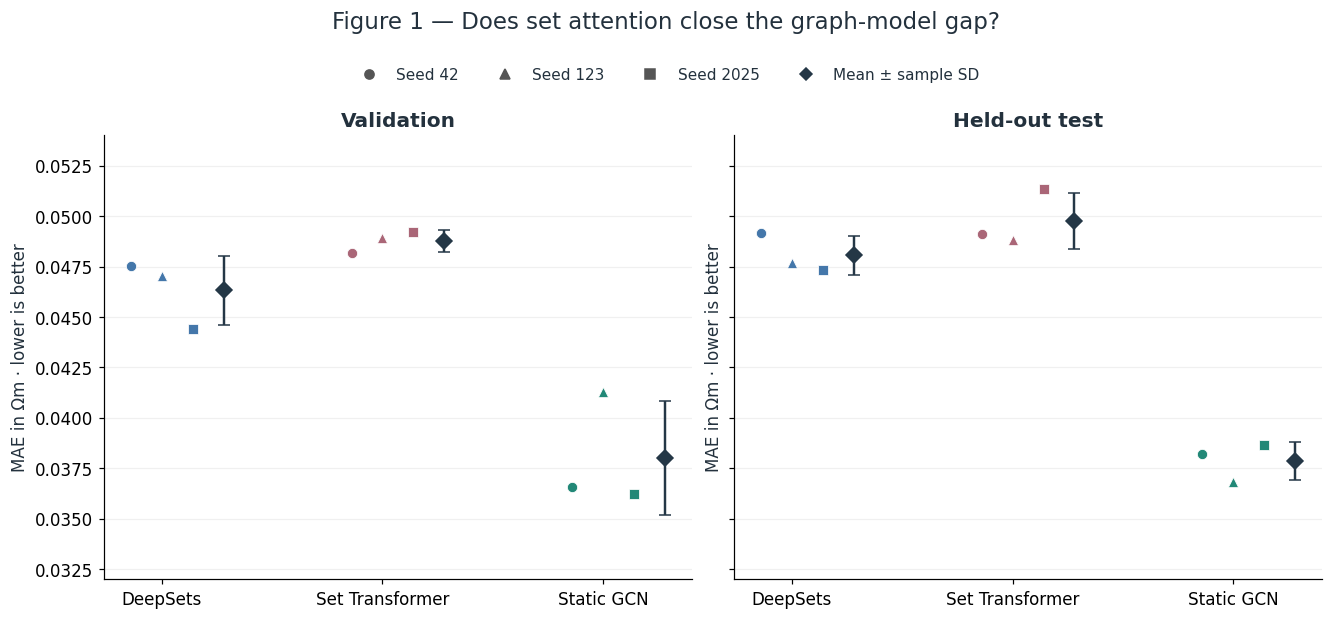

**Question.** Does set attention improve the unordered-set baseline or approach Static GCN?

**Observation.** DeepSets: test MAE 0.048051 ± 0.000986; Set Transformer: test MAE 0.049768 ± 0.001383; Static GCN: test MAE 0.037887 ± 0.000942.

**Interpretation.** The frozen Set Transformer has a higher mean error than both controls; generic attention did not recover the graph advantage.

**Limitation.** Three seeds describe variability; these are not parameter-matched architectures or confidence intervals.

In [4]:
def seed_summary(ax, frame, value, models=CONTROLLED, reference=None):
    for i, model in enumerate(models):
        q = frame[frame.model == model].set_index('seed').loc[SEEDS, value]
        color = COLORS[model]
        for j, seed in enumerate(SEEDS):
            ax.scatter(i + [-.14, 0, .14][j], q.loc[seed], marker=MARKERS[seed], s=45,
                       color=color, edgecolors='white', linewidths=.5, zorder=4)
        ax.errorbar(i + .28, q.mean(), yerr=q.std(ddof=DDOF), fmt='D', color='#243746',
                    markersize=7, capsize=4, linewidth=1.6, zorder=3)
    ax.set_xticks(range(len(models)), models)
    ax.grid(axis='y', alpha=.18)
    if reference is not None: ax.axhline(reference, color='#777777', ls='--', lw=1)
def seed_legend(fig, anchor=(.5, 1.02)):
    handles = [Line2D([], [], marker=MARKERS[s], color='#555555', linestyle='none', label=f'Seed {s}') for s in SEEDS]
    handles += [Line2D([], [], marker='D', color='#243746', linestyle='none', label='Mean ± sample SD')]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=anchor, ncol=4, frameon=False, fontsize=10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True, layout='constrained')
for ax, value, title in zip(axes, ['val_mae', 'test_mae'], ['Validation', 'Held-out test']):
    seed_summary(ax, controlled_seed, value); ax.set_title(title); ax.set_ylabel('MAE in Ωm · lower is better')
    ax.set_ylim(.032, .054)
fig.suptitle('Figure 1 — Does set attention close the graph-model gap?', y=1.19, fontsize=15)
seed_legend(fig)
savefig(fig, 'fig01_controlled_mae_comparison')
a = all_aggregate
caption('Does set attention improve the unordered-set baseline or approach Static GCN?',
        '; '.join(f'{m}: test MAE {pm(a.loc[m,"test_mae_mean"], a.loc[m,"test_mae_sd"])}' for m in CONTROLLED) + '.',
        'The frozen Set Transformer has a higher mean error than both controls; generic attention did not recover the graph advantage.',
        'Three seeds describe variability; these are not parameter-matched architectures or confidence intervals.')

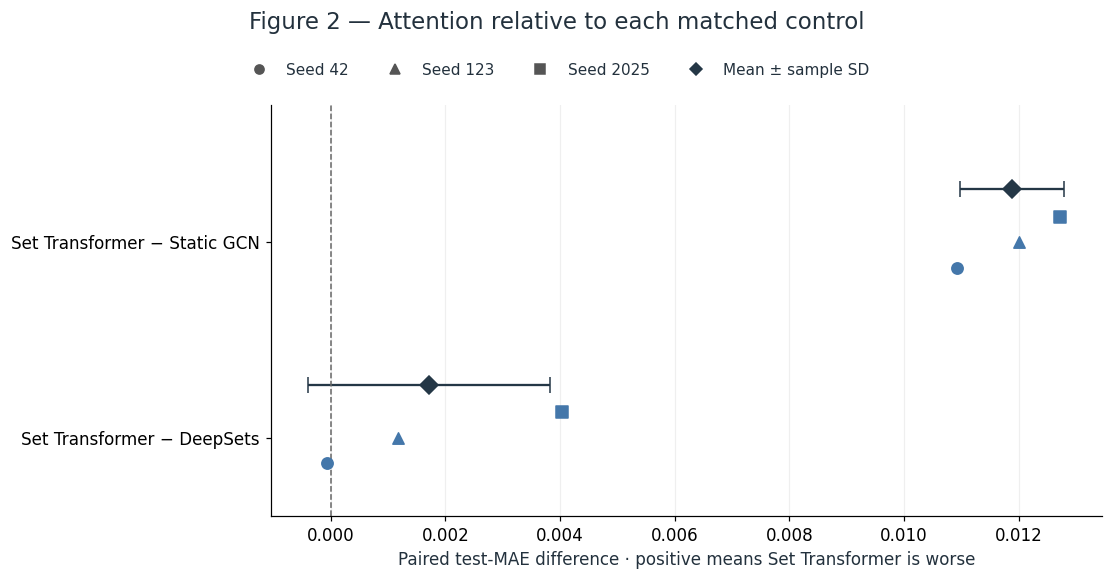

**Question.** Is the aggregate result consistent across matched seeds?

**Observation.** Set Transformer − DeepSets: 0.001717 ± 0.002105; Set Transformer − Static GCN: 0.011881 ± 0.000909. ST is worse than DeepSets in 2/3 seeds and worse than Static GCN in 3/3.

**Interpretation.** The graph gap is larger and more consistent than the small average DeepSets–attention difference.

**Limitation.** No significance, equivalence or universal superiority test is justified by n=3.

In [5]:
pivot = controlled_seed.pivot(index='seed', columns='model', values='test_mae').loc[SEEDS]
paired = pd.DataFrame([{'comparison': f'Set Transformer − {m}', 'seed': s,
                       'test_mae_difference': pivot.loc[s, 'Set Transformer'] - pivot.loc[s, m]}
                      for m in ['DeepSets', 'Static GCN'] for s in SEEDS])
paired_summary = paired.groupby('comparison', sort=False).test_mae_difference.agg(mean='mean', sd=lambda x: x.std(ddof=DDOF))
for m in ['DeepSets', 'Static GCN']:
    r = paired_summary.loc[f'Set Transformer − {m}']
    assert abs(r['mean'] - freeze['paired_test_mae_differences'][m]['mean']) <= TOL
    assert abs(r['sd'] - freeze['paired_test_mae_differences'][m]['sample_sd']) <= TOL
table(paired, 'table04_paired_mae_differences.csv', show=False)
fig, ax = plt.subplots(figsize=(10, 4.3), layout='constrained')
for i, (label, group) in enumerate(paired.groupby('comparison', sort=False)):
    for j, row in enumerate(group.itertuples()):
        ax.scatter(row.test_mae_difference, i + [-.13, 0, .13][j], marker=MARKERS[row.seed], s=55, color='#4477AA', zorder=4)
    q = paired_summary.loc[label]
    ax.errorbar(q['mean'], i + .27, xerr=q['sd'], fmt='D', color='#243746', capsize=5, markersize=8)
ax.axvline(0, color='#666666', ls='--', lw=1)
ax.set_yticks([0, 1], paired_summary.index)
ax.set_ylim(-.4, 1.7); ax.grid(axis='x', alpha=.2)
ax.set_xlabel('Paired test-MAE difference · positive means Set Transformer is worse')
fig.suptitle('Figure 2 — Attention relative to each matched control', y=1.19, fontsize=15)
seed_legend(fig)
savefig(fig, 'fig02_paired_test_mae_differences')
caption('Is the aggregate result consistent across matched seeds?',
        '; '.join(f'{label}: {pm(r["mean"], r["sd"])}' for label, r in paired_summary.iterrows()) +
        f'. ST is worse than DeepSets in {(pivot["Set Transformer"] > pivot["DeepSets"]).sum()}/3 seeds and worse than Static GCN in 3/3.',
        'The graph gap is larger and more consistent than the small average DeepSets–attention difference.',
        'No significance, equivalence or universal superiority test is justified by n=3.')

# 6. Prediction Behaviour
Figures 3–6 show the same 201 seed-42 test universes. Axes retain the complete target and prediction ranges. The sorted figure uses one ordering by **true Ωm**, applied to every model; predicted values are never independently sorted.

For residual trends we predefine **five equal-width bins over Ωm ∈ [0.1, 0.5]**, include the right endpoint in the last bin, and report counts. This fixed rule is shared by every model and seed; bin means are descriptive, without inferred uncertainty bands.

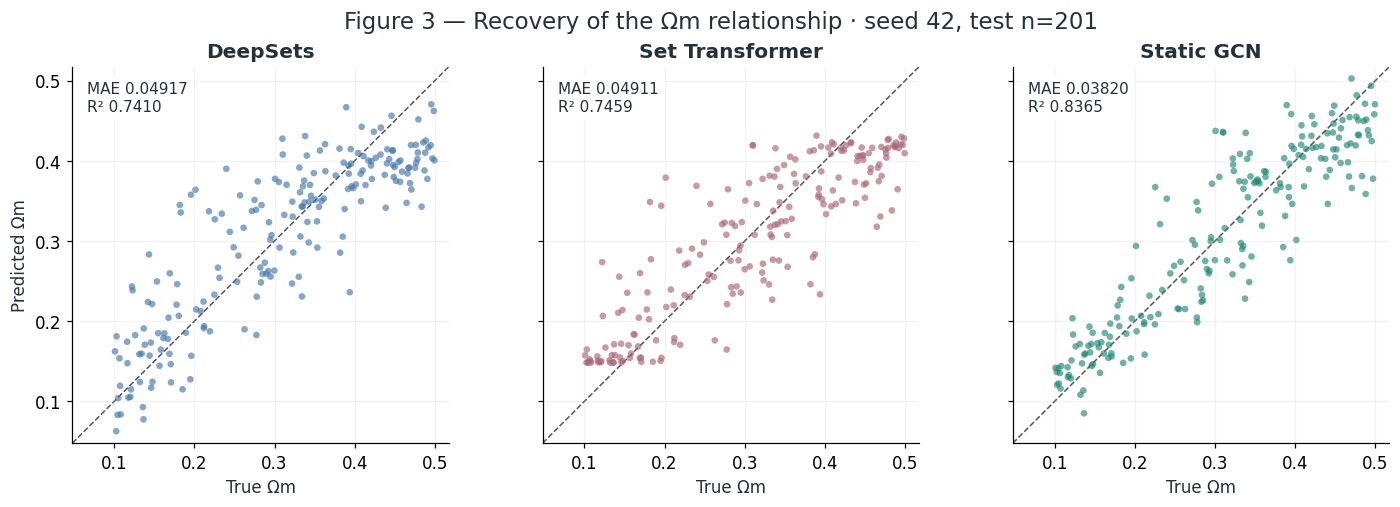

**Question.** Do the models recover the full target relationship?

**Observation.** DeepSets: MAE 0.04917, R² 0.7410; Set Transformer: MAE 0.04911, R² 0.7459; Static GCN: MAE 0.03820, R² 0.8365.

**Interpretation.** All three recover predictive information; Static GCN has lower error. Departures from identity at the extremes motivate the compression diagnostics.

**Limitation.** These are seed-42 visual diagnostics; all-seed numerical conclusions appear in Figure 7 and the supplement.

In [6]:
diagnostic_rows = []
for model in CONTROLLED:
    for seed in SEEDS:
        frame = predictions[model, seed, 'test']
        y = frame.true_omega_m.to_numpy(dtype=np.float64); p = frame.pred_omega_m.to_numpy(dtype=np.float64)
        e = p - y; absolute = np.abs(e); slope, intercept = np.polyfit(y, p, 1)
        diagnostic_rows.append({'model': model, 'seed': seed, **metrics_of(frame),
            'median_absolute_error': np.median(absolute), 'p90_absolute_error': np.quantile(absolute, .9),
            'max_absolute_error': absolute.max(), 'bias': e.mean(), 'residual_sd': e.std(ddof=DDOF),
            'true_mean': y.mean(), 'true_std': y.std(ddof=DDOF), 'true_min': y.min(), 'true_max': y.max(),
            'predicted_mean': p.mean(), 'predicted_std': p.std(ddof=DDOF), 'predicted_min': p.min(), 'predicted_max': p.max(),
            'spread_ratio': p.std(ddof=DDOF) / y.std(ddof=DDOF), 'intercept': intercept, 'slope': slope})
diagnostics = pd.DataFrame(diagnostic_rows)
table(diagnostics, 'table05_prediction_diagnostics.csv', show=False)
diagnostic_aggregate = aggregate(diagnostics, [x for x in diagnostics.columns if x not in ['model', 'seed']])
d = diagnostic_aggregate.set_index('model')
BINS = np.linspace(.1, .5, 6)
bin_rows = []
for model in CONTROLLED:
    for seed in SEEDS:
        frame = predictions[model, seed, 'test']; y = frame.true_omega_m.to_numpy(); e = frame.pred_omega_m.to_numpy() - y
        assert y.min() >= BINS[0] and y.max() <= BINS[-1]
        labels = np.minimum(np.searchsorted(BINS, y, side='right') - 1, len(BINS) - 2)
        for i in range(5):
            mask = labels == i
            assert mask.sum() >= 10, (model, seed, i)
            bin_rows.append({'model': model, 'seed': seed, 'bin': i, 'left': BINS[i], 'right': BINS[i+1],
                             'count': int(mask.sum()), 'true_mean': y[mask].mean(), 'residual_mean': e[mask].mean()})
binned = pd.DataFrame(bin_rows)

def prediction_panels(seed, name, title):
    values = np.concatenate([predictions[m, seed, 'test'][['true_omega_m', 'pred_omega_m']].to_numpy().ravel() for m in CONTROLLED])
    limits = (min(.1, values.min()) - .015, max(.5, values.max()) + .015)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True, layout='constrained')
    for ax, model in zip(axes, CONTROLLED):
        frame = predictions[model, seed, 'test']; metric = metrics_of(frame)
        ax.scatter(frame.true_omega_m, frame.pred_omega_m, color=COLORS[model], s=19, alpha=.65, edgecolors='none')
        ax.plot(limits, limits, color='#555555', ls='--', lw=1, zorder=0)
        ax.set(xlim=limits, ylim=limits, xlabel='True Ωm', title=model, aspect='equal')
        ax.text(.04, .96, f'MAE {metric["mae"]:.5f}\nR² {metric["r2"]:.4f}', transform=ax.transAxes,
                va='top', fontsize=10, bbox={'facecolor':'white', 'alpha':.85, 'edgecolor':'none'})
        ax.grid(alpha=.15)
    axes[0].set_ylabel('Predicted Ωm')
    fig.suptitle(title, fontsize=15)
    savefig(fig, name)
prediction_panels(CANONICAL_SEED, 'fig03_true_vs_predicted_seed42', 'Figure 3 — Recovery of the Ωm relationship · seed 42, test n=201')
s42 = diagnostics[diagnostics.seed == CANONICAL_SEED].set_index('model')
caption('Do the models recover the full target relationship?',
        '; '.join(f'{m}: MAE {s42.loc[m,"mae"]:.5f}, R² {s42.loc[m,"r2"]:.4f}' for m in CONTROLLED) + '.',
        'All three recover predictive information; Static GCN has lower error. Departures from identity at the extremes motivate the compression diagnostics.',
        'These are seed-42 visual diagnostics; all-seed numerical conclusions appear in Figure 7 and the supplement.')

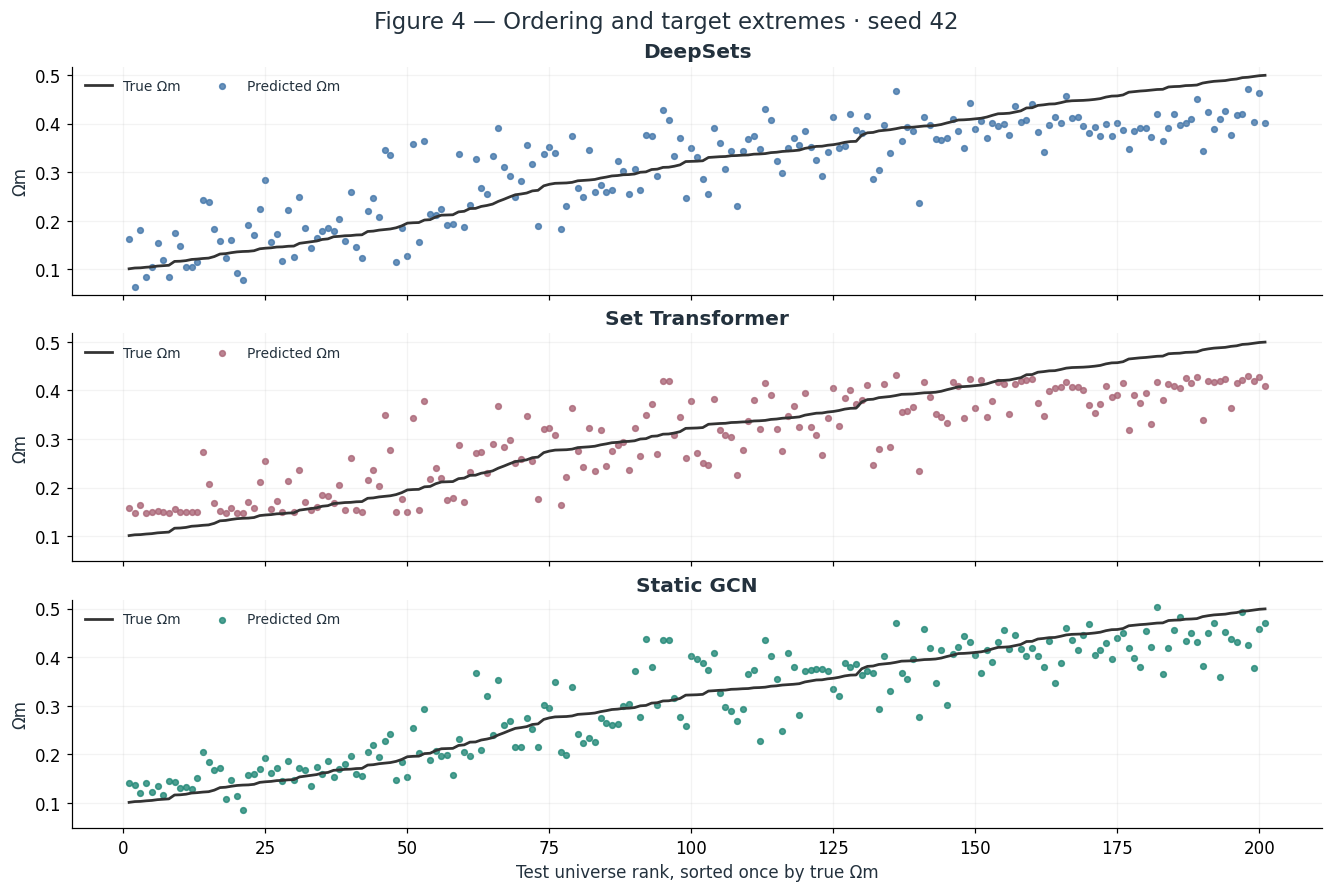

**Question.** Does prediction flatten when universes are ordered by their true target?

**Observation.** DeepSets: predicted range [0.063, 0.470]; Set Transformer: predicted range [0.148, 0.431]; Static GCN: predicted range [0.085, 0.503]; true range [0.101, 0.499].

**Interpretation.** The models track the overall ordering but scatter and central regression remain; neither set model reproduces every extreme.

**Limitation.** A sample min/max is sensitive to isolated points; spread and slope across all seeds provide stronger compression evidence.

In [7]:
ordered_ids = predictions['DeepSets', CANONICAL_SEED, 'test'].sort_values('true_omega_m', kind='stable').universe_id
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True, layout='constrained')
all_values = np.concatenate([predictions[m, CANONICAL_SEED, 'test'][['true_omega_m', 'pred_omega_m']].to_numpy().ravel() for m in CONTROLLED])
for ax, model in zip(axes, CONTROLLED):
    frame = predictions[model, CANONICAL_SEED, 'test'].set_index('universe_id').loc[ordered_ids]
    x = np.arange(1, 202)
    ax.plot(x, frame.true_omega_m, color='#333333', lw=1.8, label='True Ωm')
    ax.scatter(x, frame.pred_omega_m, color=COLORS[model], s=14, alpha=.8, label='Predicted Ωm')
    ax.set(title=model, ylabel='Ωm', ylim=(min(.1, all_values.min())-.015, max(.5, all_values.max())+.015))
    ax.grid(alpha=.15); ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=9)
axes[-1].set_xlabel('Test universe rank, sorted once by true Ωm')
fig.suptitle('Figure 4 — Ordering and target extremes · seed 42', fontsize=15)
savefig(fig, 'fig04_sorted_predictions_seed42')
caption('Does prediction flatten when universes are ordered by their true target?',
        '; '.join(f'{m}: predicted range [{s42.loc[m,"predicted_min"]:.3f}, {s42.loc[m,"predicted_max"]:.3f}]' for m in CONTROLLED) +
        f'; true range [{s42.true_min.iloc[0]:.3f}, {s42.true_max.iloc[0]:.3f}].',
        'The models track the overall ordering but scatter and central regression remain; neither set model reproduces every extreme.',
        'A sample min/max is sensitive to isolated points; spread and slope across all seeds provide stronger compression evidence.')

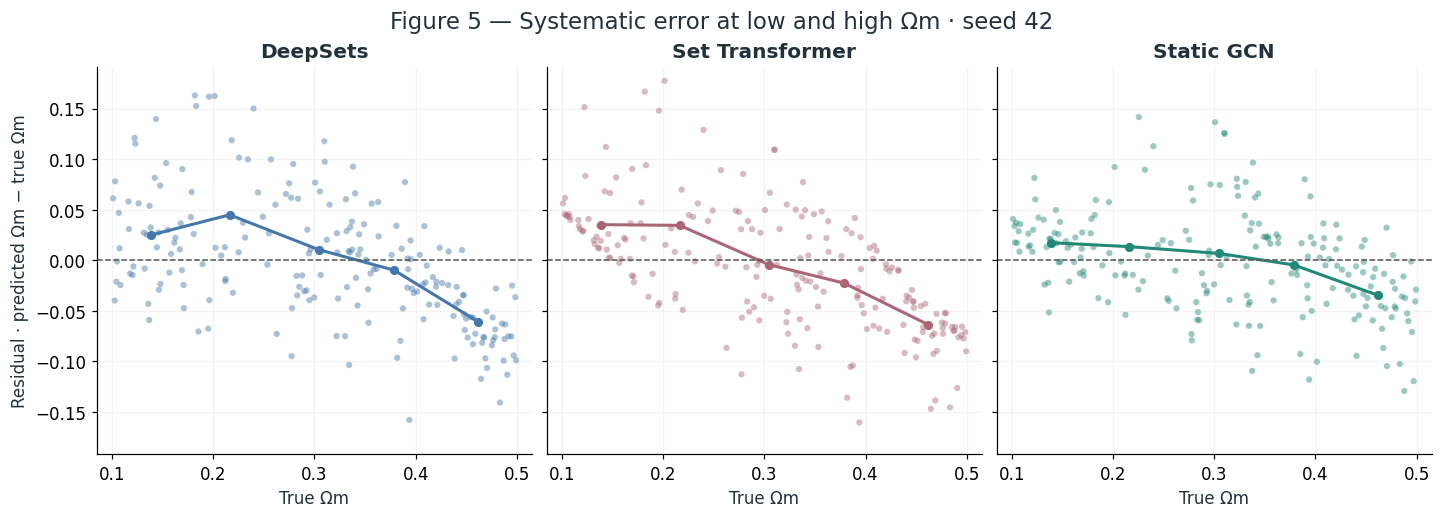

left,right,count
0.10,0.18,44
0.18,0.26,27
0.26,0.34,42
0.34,0.42,40
0.42,0.50,48


**Question.** Are errors structureless or systematically dependent on Ωm?

**Observation.** DeepSets: low/high-bin mean residual +0.0250/-0.0608; Set Transformer: low/high-bin mean residual +0.0353/-0.0637; Static GCN: low/high-bin mean residual +0.0175/-0.0347.

**Interpretation.** Positive low-target and negative high-target trends are consistent with regression toward the center.

**Limitation.** Fixed-bin means describe this partition; they do not identify a physical cause or provide independent confidence bands.

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharex=True, sharey=True, layout='constrained')
residual_limit = max(np.abs(predictions[m, CANONICAL_SEED, 'test'].pred_omega_m - predictions[m, CANONICAL_SEED, 'test'].true_omega_m).max() for m in CONTROLLED) * 1.08
for ax, model in zip(axes, CONTROLLED):
    frame = predictions[model, CANONICAL_SEED, 'test']; q = binned[(binned.model == model) & (binned.seed == CANONICAL_SEED)]
    ax.scatter(frame.true_omega_m, frame.pred_omega_m-frame.true_omega_m, color=COLORS[model], s=17, alpha=.45, edgecolors='none')
    ax.plot(q.true_mean, q.residual_mean, '-o', color=COLORS[model], lw=2, ms=5, label='Fixed-bin mean')
    ax.axhline(0, color='#555555', ls='--', lw=1)
    ax.set(title=model, xlabel='True Ωm', xlim=(.085, .515), ylim=(-residual_limit, residual_limit))
    ax.grid(alpha=.15)
axes[0].set_ylabel('Residual · predicted Ωm − true Ωm')
fig.suptitle('Figure 5 — Systematic error at low and high Ωm · seed 42', fontsize=15)
savefig(fig, 'fig05_residual_structure_seed42')
counts = binned[(binned.model == 'DeepSets') & (binned.seed == CANONICAL_SEED)][['left', 'right', 'count']]
display(counts.style.hide(axis='index').format({'left':'{:.2f}', 'right':'{:.2f}'}))
endpoints = binned[binned.seed == CANONICAL_SEED].set_index(['model', 'bin'])
caption('Are errors structureless or systematically dependent on Ωm?',
        '; '.join(f'{m}: low/high-bin mean residual {endpoints.loc[(m,0),"residual_mean"]:+.4f}/{endpoints.loc[(m,4),"residual_mean"]:+.4f}' for m in CONTROLLED) + '.',
        'Positive low-target and negative high-target trends are consistent with regression toward the center.',
        'Fixed-bin means describe this partition; they do not identify a physical cause or provide independent confidence bands.')

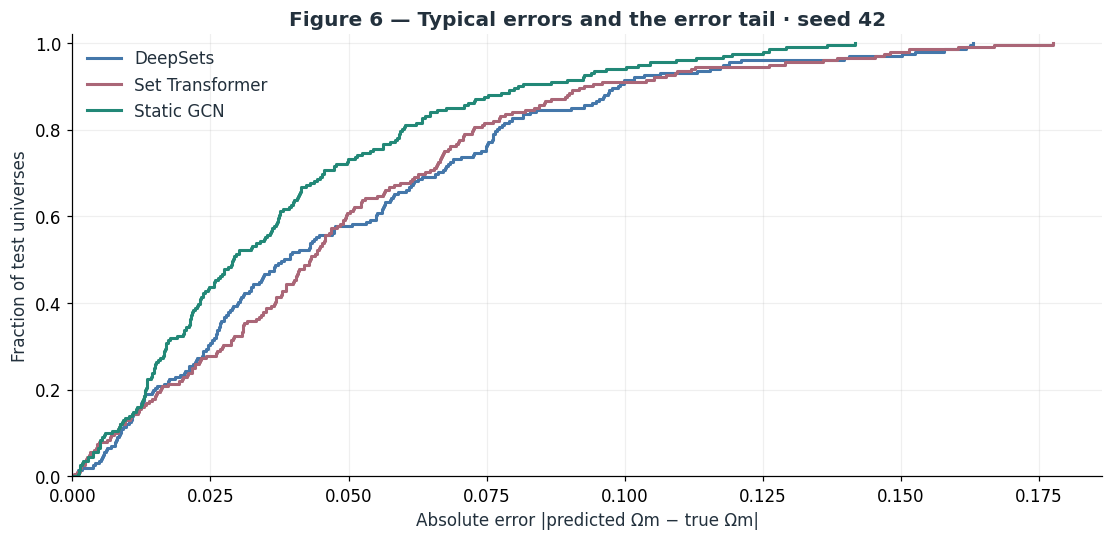

model,mae,median_absolute_error,p90_absolute_error,max_absolute_error
DeepSets,0.04917,0.03834,0.09883,0.16303
Set Transformer,0.04911,0.04297,0.09256,0.17750
Static GCN,0.03820,0.02913,0.08071,0.14173


**Question.** Is poorer MAE due to typical errors, extreme failures, or both?

**Observation.** DeepSets: median 0.0383, 90th percentile 0.0988, maximum 0.1630; Set Transformer: median 0.0430, 90th percentile 0.0926, maximum 0.1775; Static GCN: median 0.0291, 90th percentile 0.0807, maximum 0.1417.

**Interpretation.** The ECDF separates central accuracy from tail errors. The Static GCN advantage extends beyond the single largest error.

**Limitation.** ECDF curves may cross; this is not a claim of stochastic dominance. Tail statistics are diagnostics, not replacement selection metrics.

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
for model in CONTROLLED:
    frame = predictions[model, CANONICAL_SEED, 'test']; error = np.sort(np.abs(frame.pred_omega_m-frame.true_omega_m))
    ax.step(np.r_[0,error], np.r_[0,np.arange(1,202)/201], where='post', color=COLORS[model], lw=2, label=model)
ax.set(xlabel='Absolute error |predicted Ωm − true Ωm|', ylabel='Fraction of test universes', ylim=(0,1.02), xlim=(0,None))
ax.set_title('Figure 6 — Typical errors and the error tail · seed 42')
ax.legend(frameon=False); ax.grid(alpha=.2)
savefig(fig, 'fig06_absolute_error_distribution_seed42')
display(s42[['mae','median_absolute_error','p90_absolute_error','max_absolute_error']].reset_index().style.hide(axis='index').format(precision=5))
caption('Is poorer MAE due to typical errors, extreme failures, or both?',
        '; '.join(f'{m}: median {s42.loc[m,"median_absolute_error"]:.4f}, 90th percentile {s42.loc[m,"p90_absolute_error"]:.4f}, maximum {s42.loc[m,"max_absolute_error"]:.4f}' for m in CONTROLLED) + '.',
        'The ECDF separates central accuracy from tail errors. The Static GCN advantage extends beyond the single largest error.',
        'ECDF curves may cross; this is not a claim of stochastic dominance. Tail statistics are diagnostics, not replacement selection metrics.')

# 7. Prediction Compression and Calibration
We calculate `std(predicted Ωm) / std(true Ωm)` and fit the descriptive least-squares relation `predicted Ωm = intercept + slope × true Ωm`. The ideal identity relation has spread ratio and slope equal to 1. Values below 1 are consistent with compression, but scatter also affects the spread ratio.

This is **not formal probabilistic calibration**, and the fitted relation is never used to correct predictions. Bias, intercepts, ranges and residual SDs remain available in the diagnostic tables.

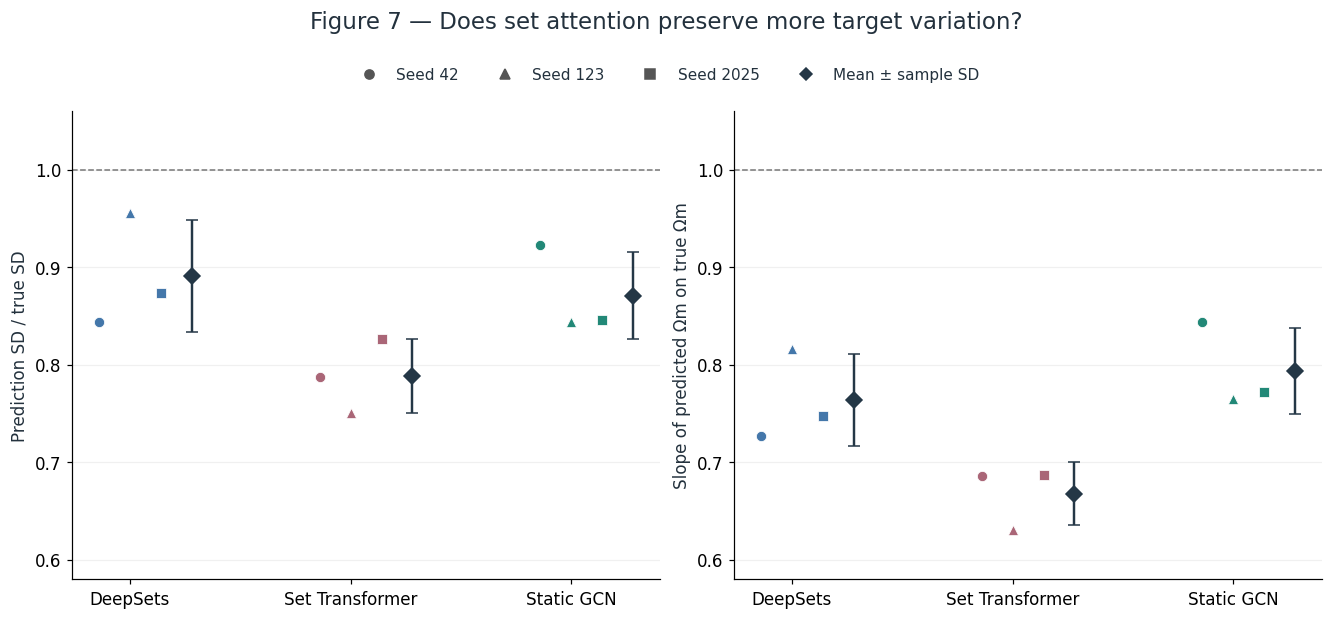

model,spread ratio,slope,bias
DeepSets,0.890994 ± 0.057596,0.763619 ± 0.046931,-0.000170 ± 0.006730
Set Transformer,0.788419 ± 0.038070,0.667956 ± 0.031962,-0.002368 ± 0.005064
Static GCN,0.870902 ± 0.044981,0.793589 ± 0.044003,0.002156 ± 0.003763


**Question.** Which representation best preserves the dynamic range of Ωm?

**Observation.** DeepSets: spread 0.8910 ± 0.0576, slope 0.7636 ± 0.0469; Set Transformer: spread 0.7884 ± 0.0381, slope 0.6680 ± 0.0320; Static GCN: spread 0.8709 ± 0.0450, slope 0.7936 ± 0.0440.

**Interpretation.** Set Transformer has the lowest mean spread ratio and slope, indicating stronger compression. Static GCN has the slope closest to one; DeepSets has a slightly wider spread but higher error. A wide noisy prediction distribution alone is not faithful target recovery.

**Limitation.** These descriptive fits neither estimate predictive uncertainty nor establish a mechanism for compression.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout='constrained')
for ax, value, label in zip(axes, ['spread_ratio','slope'], ['Prediction SD / true SD','Slope of predicted Ωm on true Ωm']):
    seed_summary(ax, diagnostics, value, reference=1); ax.set_ylabel(label); ax.set_ylim(.58,1.06)
fig.suptitle('Figure 7 — Does set attention preserve more target variation?', y=1.19, fontsize=15)
seed_legend(fig)
savefig(fig, 'fig07_prediction_compression_and_calibration')
display(pd.DataFrame([{'model':m, 'spread ratio':pm(d.loc[m,'spread_ratio_mean'],d.loc[m,'spread_ratio_sd']),
                      'slope':pm(d.loc[m,'slope_mean'],d.loc[m,'slope_sd']),
                      'bias':pm(d.loc[m,'bias_mean'],d.loc[m,'bias_sd'])} for m in CONTROLLED]).style.hide(axis='index'))
caption('Which representation best preserves the dynamic range of Ωm?',
        '; '.join(f'{m}: spread {pm(d.loc[m,"spread_ratio_mean"],d.loc[m,"spread_ratio_sd"],4)}, slope {pm(d.loc[m,"slope_mean"],d.loc[m,"slope_sd"],4)}' for m in CONTROLLED) + '.',
        'Set Transformer has the lowest mean spread ratio and slope, indicating stronger compression. Static GCN has the slope closest to one; DeepSets has a slightly wider spread but higher error. A wide noisy prediction distribution alone is not faithful target recovery.',
        'These descriptive fits neither estimate predictive uncertainty nor establish a mechanism for compression.')

# 8. Capacity / Parameter-Efficiency Diagnostic
Parameter counts come from the independently audited closure and saved metadata. This diagnostic asks whether simply having more parameters is sufficient to explain accuracy; it does not measure runtime, memory efficiency, or a causal effect of graph topology.

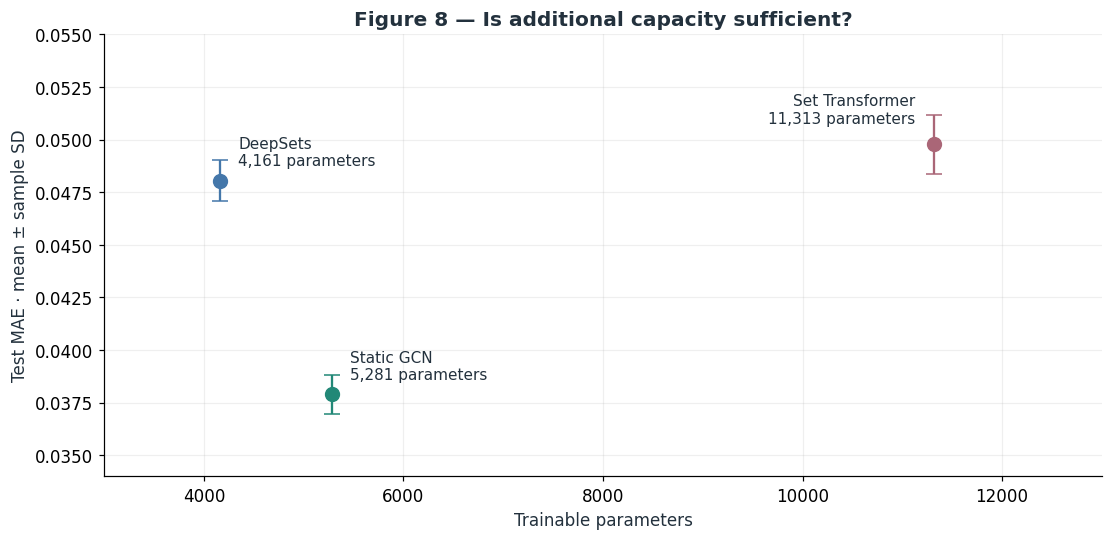

**Question.** Could Static GCN win merely because it has more parameters?

**Observation.** Set Transformer has 2.14× the Static GCN parameter count, yet its mean test MAE is higher by 0.011881.

**Interpretation.** More parameters are insufficient to explain the Static GCN advantage in this comparison.

**Limitation.** Only three architectures are shown. Capacity, depth and optimization differ; no regression line or topology-causality claim is warranted.

In [11]:
fig, ax = plt.subplots(figsize=(10,4.8), layout='constrained')
for model in CONTROLLED:
    q = all_aggregate.loc[model]
    ax.errorbar(PARAMS[model], q.test_mae_mean, yerr=q.test_mae_sd, fmt='o', color=COLORS[model], ms=9, capsize=5)
    offset = (-12,14) if model == 'Set Transformer' else (12,10)
    ax.annotate(f'{model}\n{PARAMS[model]:,} parameters', (PARAMS[model],q.test_mae_mean), xytext=offset,
                textcoords='offset points', ha='right' if model=='Set Transformer' else 'left', fontsize=10)
ax.set(xlabel='Trainable parameters', ylabel='Test MAE · mean ± sample SD', xlim=(3000,13000), ylim=(.034,.055))
ax.grid(alpha=.2); ax.set_title('Figure 8 — Is additional capacity sufficient?')
savefig(fig, 'fig08_parameter_count_vs_test_mae')
caption('Could Static GCN win merely because it has more parameters?',
        f'Set Transformer has {PARAMS["Set Transformer"] / PARAMS["Static GCN"]:.2f}× the Static GCN parameter count, '
        f'yet its mean test MAE is higher by {paired_summary.loc["Set Transformer − Static GCN","mean"]:.6f}.',
        'More parameters are insufficient to explain the Static GCN advantage in this comparison.',
        'Only three architectures are shown. Capacity, depth and optimization differ; no regression line or topology-causality claim is warranted.')

# 9. Scientific Verdict for the Controlled Experiment
The verdict concerns the frozen architecture and protocol. It is not a statement that attention never works, that GCNs are universally superior, or that topology alone has been causally isolated.

In [12]:
display(Markdown(
    f'**Q1 — Attention over DeepSets:** not supported by mean MAE. Set Transformer changes test MAE by '
    f'{paired_summary.loc["Set Transformer − DeepSets","mean"]:+.6f}; it narrowly improves seed 42 but is worse on the other two seeds.\n\n'
    f'**Q2 — Closing the graph gap:** not supported. Set Transformer is worse than Static GCN in every seed, '
    f'with paired mean difference {paired_summary.loc["Set Transformer − Static GCN","mean"]:+.6f}.\n\n'
    f'**Q3 — Capacity alone:** insufficient. The largest controlled model has {PARAMS["Set Transformer"]:,} parameters '
    f'and does not recover the accuracy of the {PARAMS["Static GCN"]:,}-parameter Static GCN.\n\n'
    '**Q4 — Prediction behavior:** all three models carry Ωm information, but residual structure and sub-unit '
    'slopes expose remaining regression toward the center. Set Transformer has the strongest mean compression on both diagnostics. Static GCN has the highest mean slope, while DeepSets has the widest spread. Figure 7 quantifies this across seeds; seed-42 panels are illustrative.'
))

**Q1 — Attention over DeepSets:** not supported by mean MAE. Set Transformer changes test MAE by +0.001717; it narrowly improves seed 42 but is worse on the other two seeds.

**Q2 — Closing the graph gap:** not supported. Set Transformer is worse than Static GCN in every seed, with paired mean difference +0.011881.

**Q3 — Capacity alone:** insufficient. The largest controlled model has 11,313 parameters and does not recover the accuracy of the 5,281-parameter Static GCN.

**Q4 — Prediction behavior:** all three models carry Ωm information, but residual structure and sub-unit slopes expose remaining regression toward the center. Set Transformer has the strongest mean compression on both diagnostics. Static GCN has the highest mean slope, while DeepSets has the widest spread. Figure 7 quantifies this across seeds; seed-42 panels are illustrative.

# 10. Thesis-Wide Model Comparison
**Q5 — Where do these representations sit in the full predictive landscape?**

> This figure summarizes the principal models evaluated in the thesis. It is not a single controlled architecture ablation: summary models use engineered catalogue statistics, raw-set models use final-snapshot halo features, static graph models additionally use explicit connectivity, and temporal graph models use five snapshots. Matching splits improves fairness, but input information is still different. The broad ranking is predictive benchmarking, not pure causal architecture attribution.

All applicable rows use frozen U1000/Top1500/train700 configurations and the same seed-specific validation/test partitions. The mean baseline uses only training targets and is **Top-N independent**. Gradient Boosting is the unchanged frozen Top1500 choice; Top2000 is not substituted on the basis of its test score. EvolveGCN-O seed 123 retains its documented inference-only recovery provenance; only the finalized saved result is read here.

The family order is conceptual, not chronological. Within families, models follow a fixed architecture order. “Best” below describes the evaluated frozen benchmark and does not select a new model or alter the final-selection file.

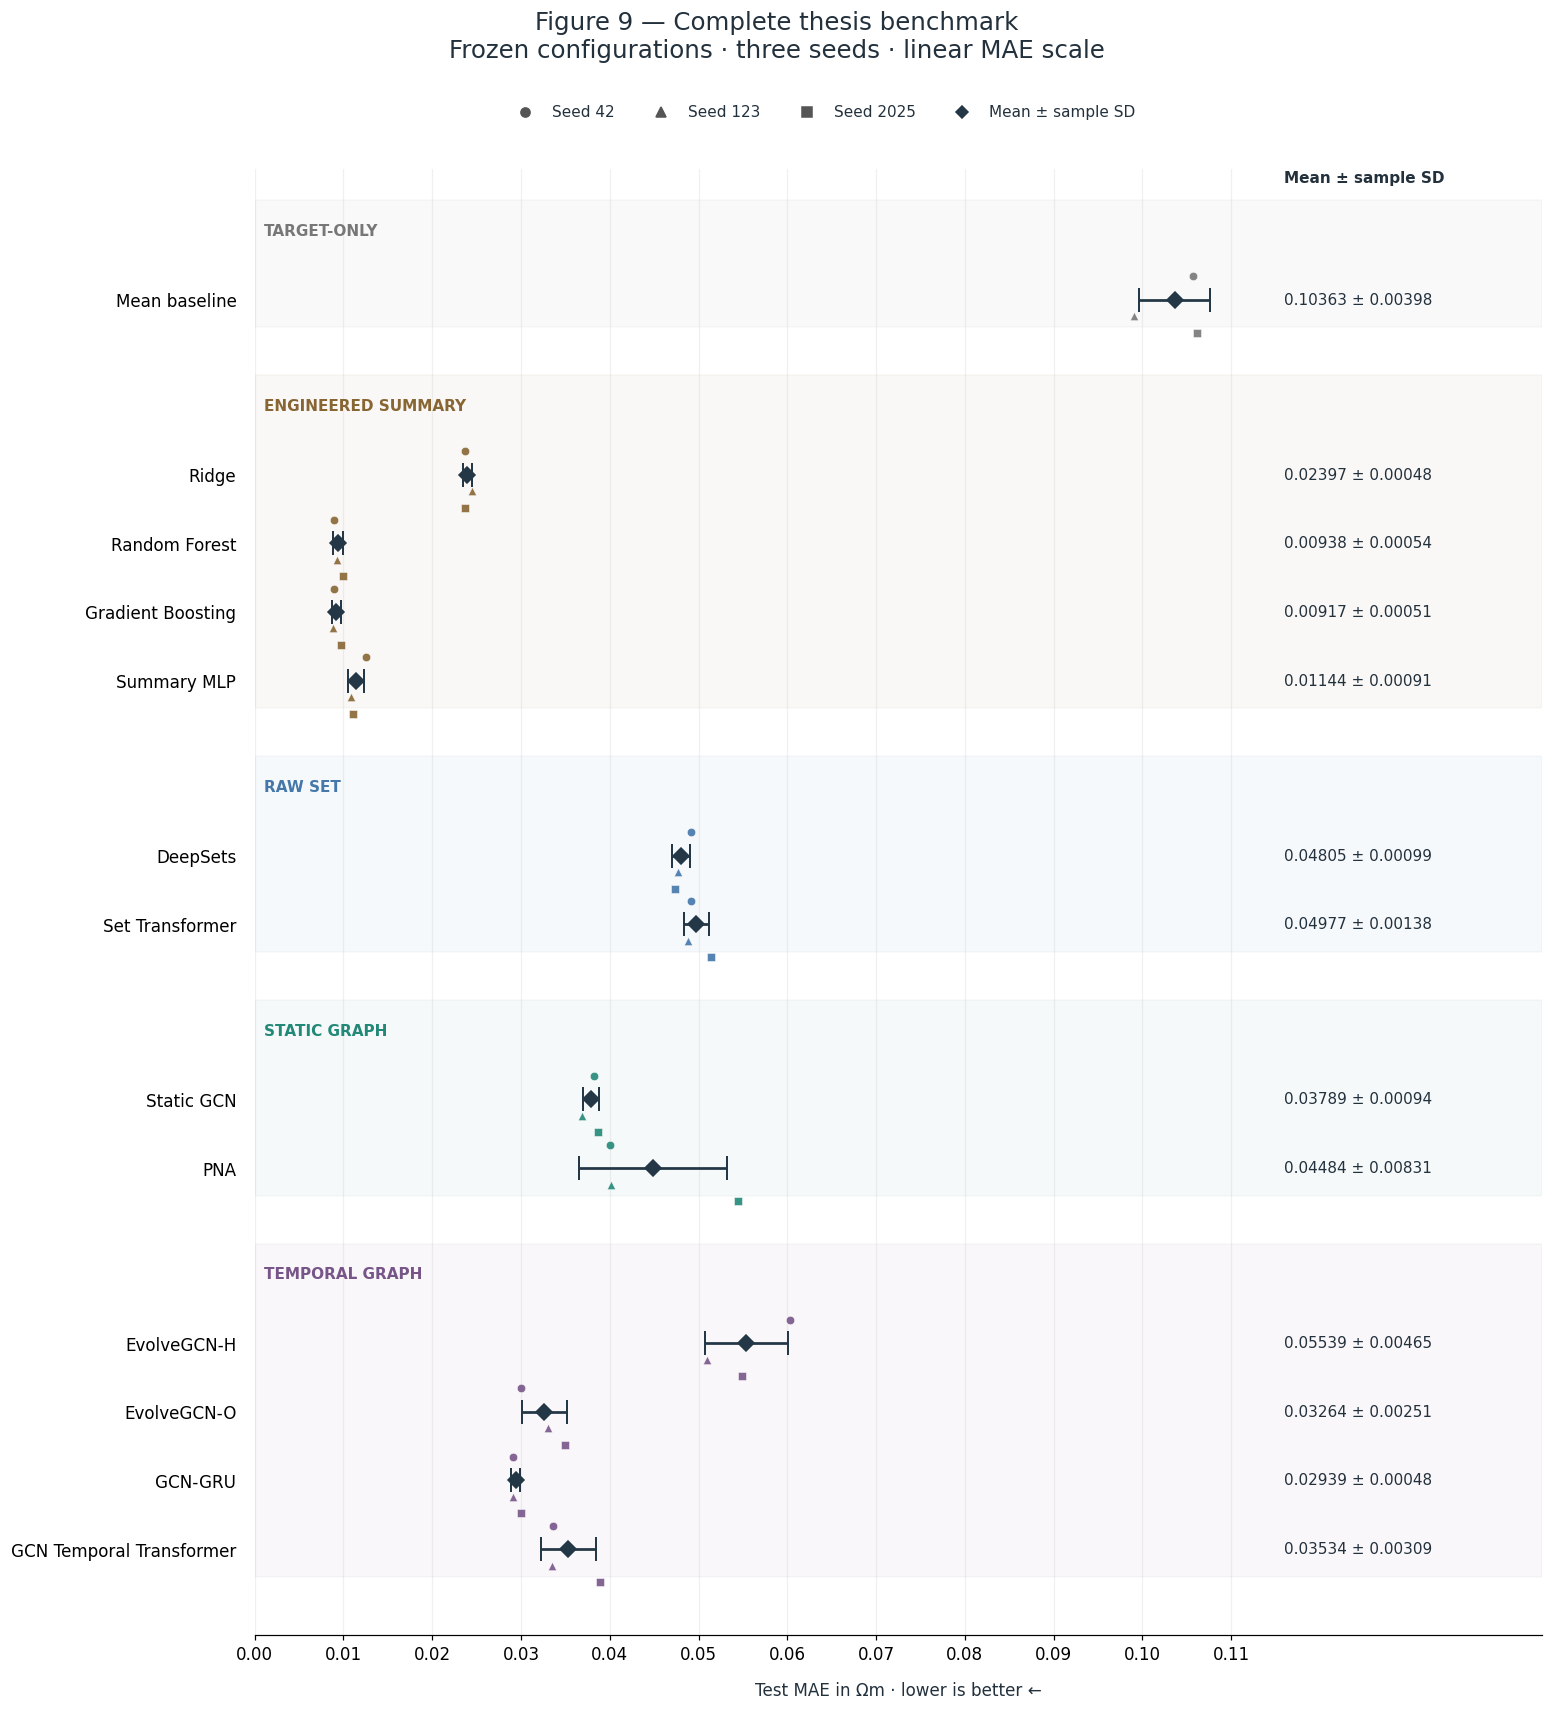

**Question.** Which frozen model and representation family predict Ωm most accurately?

**Observation.** Gradient Boosting has the lowest mean test MAE (0.009173); Random Forest follows at 0.009376. GCN-GRU leads the raw-halo/graph models at 0.029393.

**Interpretation.** Engineered summary tree models remain substantially more accurate. Temporal aggregation can improve learned graph predictions, while attention or aggregation complexity alone need not do so.

**Limitation.** This is a benchmark across different inputs, not a single controlled architecture ablation. Sample SDs across three overlapping seed splits are descriptive, not confidence intervals.

representation_family,model,static_temporal,input_information,Top-N,parameters,seeds,val_mae,test_mae,test_mse,test_rmse,test_r2
Target-only,Mean baseline,N/A,target only,N/A (independent),N/A,"42, 123, 2025",0.102224 ± 0.001606,0.103631 ± 0.003979,0.014142 ± 0.000952,0.118874 ± 0.004041,-0.005876 ± 0.004638
Engineered summary,Ridge,static,static summary20,1500,N/A,"42, 123, 2025",0.024170 ± 0.002388,0.023970 ± 0.000480,0.000915 ± 0.000021,0.030243 ± 0.000344,0.934803 ± 0.003106
Engineered summary,Random Forest,static,static summary20,1500,N/A,"42, 123, 2025",0.009587 ± 0.000884,0.009376 ± 0.000536,0.000155 ± 0.000017,0.012434 ± 0.000672,0.988963 ± 0.001192
Engineered summary,Gradient Boosting,static,static summary20,1500,N/A,"42, 123, 2025",0.008414 ± 0.000564,0.009173 ± 0.000511,0.000151 ± 0.000014,0.012294 ± 0.000568,0.989229 ± 0.000787
Engineered summary,Summary MLP,static,static summary20,1500,N/A,"42, 123, 2025",0.010300 ± 0.000791,0.011438 ± 0.000914,0.000209 ± 0.000031,0.014419 ± 0.001042,0.985176 ± 0.001703
Raw set,DeepSets,static,static raw7,1500,4161,"42, 123, 2025",0.046316 ± 0.001694,0.048051 ± 0.000986,0.003804 ± 0.000112,0.061669 ± 0.000907,0.728927 ± 0.012366
Raw set,Set Transformer,static,static raw7,1500,11313,"42, 123, 2025",0.048783 ± 0.000540,0.049768 ± 0.001383,0.004043 ± 0.000390,0.063536 ± 0.003039,0.711793 ± 0.029777
Static graph,Static GCN,static,static raw7 graph,1500,5281,"42, 123, 2025",0.038023 ± 0.002815,0.037887 ± 0.000942,0.002436 ± 0.000062,0.049348 ± 0.000624,0.826323 ± 0.010566
Static graph,PNA,static,static raw7 graph,1500,51553,"42, 123, 2025",0.045415 ± 0.009593,0.044845 ± 0.008305,0.003298 ± 0.001287,0.056757 ± 0.010753,0.766313 ± 0.084636
Temporal graph,EvolveGCN-H,temporal,"temporal raw7 graph, 5 snapshots",1500,3408097,"42, 123, 2025",0.052516 ± 0.004175,0.055392 ± 0.004653,0.007686 ± 0.005064,0.084741 ± 0.027509,0.462177 ± 0.332427


**Best within the evaluated families (descriptive):** Target-only: **Mean baseline** (0.103631); Engineered summary: **Gradient Boosting** (0.009173); Raw set: **DeepSets** (0.048051); Static graph: **Static GCN** (0.037887); Temporal graph: **GCN-GRU** (0.029393). **Overall: Gradient Boosting.** N/A parameter entries preserve unavailable/not-applicable registry values; no tree parameter counts are invented.

In [13]:
FAMILIES = {'Target-only': ['Mean baseline'],
            'Engineered summary': ['Ridge','Random Forest','Gradient Boosting','Summary MLP'],
            'Raw set': ['DeepSets','Set Transformer'],
            'Static graph': ['Static GCN','PNA'],
            'Temporal graph': ['EvolveGCN-H','EvolveGCN-O','GCN-GRU','GCN Temporal Transformer']}
family_of = {m:f for f, models in FAMILIES.items() for m in models}
assert list(family_of) == EXPECTED_MODELS
assert set(available['Gradient Boosting']['runs'][0]['run_directory'].split('_')) >= {'top1500'}
gb_selection = selection[selection.model == 'Gradient Boosting']
assert len(gb_selection) == 1 and int(gb_selection.iloc[0].top_n) == 1500
assert abs(float(gb_selection.iloc[0].test_mae_mean) - all_aggregate.loc['Gradient Boosting','test_mae_mean']) <= TOL
summary_rows = []
for model in EXPECTED_MODELS:
    params = {parameter_values[model, s] for s in SEEDS}
    assert len(params) == 1
    q = all_aggregate.loc[model]
    summary_rows.append({'representation_family': family_of[model], 'model': model,
        'static_temporal': 'temporal' if family_of[model] == 'Temporal graph' else ('N/A' if model == 'Mean baseline' else 'static'),
        'input_information': available[model]['representation'], 'Top-N': 'N/A (independent)' if model == 'Mean baseline' else '1500',
        'parameters': str(next(iter(params))), 'seeds': '42, 123, 2025',
        **{k: float(v) for k,v in q.items()}})
full_summary = pd.DataFrame(summary_rows)
table(full_summary, 'table06_all_models_summary.csv', show=False)
best_by_family = {f: min(models, key=lambda m: all_aggregate.loc[m,'test_mae_mean']) for f,models in FAMILIES.items()}
best_overall = all_aggregate.test_mae_mean.idxmin()
family_colors = dict(zip(FAMILIES, ['#777777','#886633','#4477AA','#228877','#775588']))
fig, ax = plt.subplots(figsize=(14,14), layout='constrained')
y = 0; positions = []; labels = []
for family, models in FAMILIES.items():
    # Dedicated blank header row and subtle family band keep every model on its own row.
    ax.axhspan(y-.45, y+len(models)+.4, color=family_colors[family], alpha=.045, zorder=0)
    ax.text(.001, y, family.upper(), fontsize=10, weight='bold', color=family_colors[family], va='center')
    y += 1
    for model in models:
        positions.append(y); labels.append(model)
        q = all_seed[all_seed.model == model].set_index('seed').loc[SEEDS, 'test_mae']
        for j, seed in enumerate(SEEDS):
            ax.scatter(q.loc[seed], y+[-.34,.24,.48][j], marker=MARKERS[seed], s=30,
                       color=family_colors[family], alpha=.9, zorder=4, edgecolors='white', linewidths=.35)
        ax.errorbar(q.mean(), y, xerr=q.std(ddof=DDOF), fmt='D', color='#243746',
                    ms=7, capsize=8, capthick=1.3, elinewidth=1.8, zorder=5)
        ax.text(.116, y, pm(q.mean(),q.std(ddof=DDOF),5), va='center', fontsize=10)
        y += 1
    y += .55
assert len(labels) == len(set(labels)) == 13 and labels == EXPECTED_MODELS
ax.set_yticks(positions,labels); ax.tick_params(axis='y',length=0,pad=12)
ax.set_ylim(y-.3,-.9); ax.set_xlim(0,.145)
ax.set_xticks(np.arange(0,.111,.01)); ax.set_xlabel('Test MAE in Ωm · lower is better ←',labelpad=12)
ax.grid(axis='x',alpha=.18); ax.spines['left'].set_visible(False)
ax.text(.116,-.7,'Mean ± sample SD',fontsize=10,weight='bold')
fig.suptitle('Figure 9 — Complete thesis benchmark\nFrozen configurations · three seeds · linear MAE scale',fontsize=16,y=1.10)
seed_legend(fig,anchor=(.53,1.02))
savefig(fig, 'fig09_all_models_test_mae_forest')
caption('Which frozen model and representation family predict Ωm most accurately?',
        f'{best_overall} has the lowest mean test MAE ({all_aggregate.loc[best_overall,"test_mae_mean"]:.6f}); '
        f'Random Forest follows at {all_aggregate.loc["Random Forest","test_mae_mean"]:.6f}. '
        f'GCN-GRU leads the raw-halo/graph models at {all_aggregate.loc["GCN-GRU","test_mae_mean"]:.6f}.',
        'Engineered summary tree models remain substantially more accurate. Temporal aggregation can improve learned graph predictions, while attention or aggregation complexity alone need not do so.',
        'This is a benchmark across different inputs, not a single controlled architecture ablation. Sample SDs across three overlapping seed splits are descriptive, not confidence intervals.')
# Full numeric data are exported above; display all requested metric summaries compactly.
presentation = full_summary[['representation_family','model','static_temporal','input_information','Top-N','parameters','seeds']].copy()
for k in metric_columns:
    presentation[k] = [pm(r[f'{k}_mean'],r[f'{k}_sd']) for _,r in full_summary.iterrows()]
display(presentation.style.hide(axis='index'))
display(Markdown('**Best within the evaluated families (descriptive):** ' + '; '.join(
    f'{f}: **{m}** ({all_aggregate.loc[m,"test_mae_mean"]:.6f})' for f,m in best_by_family.items()) +
    f'. **Overall: {best_overall}.** N/A parameter entries preserve unavailable/not-applicable registry values; no tree parameter counts are invented.'))

# 11. What the Full Thesis Evidence Now Says
The earlier [normalization study](06_normalization_ablation_top500.ipynb) found that preserving raw feature scales outperformed per-universe/per-snapshot min–max and z-score normalization in its controlled Top500 regime. This suggests that removing absolute scales can discard useful predictive information, without identifying which feature is responsible. The [Top-N study](12_u1000_topn_halo_scaling_analysis.ipynb) then found Static GCN improvement up to roughly Top1500, followed by saturation or slight reversal at Top2000. More halos alone did not remove the limitation.

The [pooling study](09_evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results.ipynb) did not support mean+max as an improvement to the tested EvolveGCN-H baseline. Thus loss of extrema through mean pooling is not a sufficient explanation. These historical studies have different universe/halo budgets; they provide context, not extra observations in the present three-seed comparison.

[Notebook 15](15_u1000_static_graph_representation_and_architecture_study.ipynb) found that PNA did not beat Static GCN and documented sensitivity to translations and rotations under fixed topology. Notebook 17 adds the complementary result: generic learned interactions without explicit edges also fail to recover the Static GCN advantage in the tested configuration. Together, these results favor a useful role for explicit periodic neighborhoods while showing that extra aggregation complexity or parameter capacity is not sufficient.

[Notebook 16](16_u1000_temporal_architecture_study.ipynb) established GCN-GRU as the validation winner of the temporal study before test reporting. Its saved test result remains the strongest learned raw-halo model in the present benchmark. Temporal information appears useful when encoded effectively; EvolveGCN-H shows that temporal input does not guarantee improvement.

The remaining gap to engineered-summary tree models points to incomplete statistical efficiency in the learned raw-halo representations. Compact catalogue statistics may make useful signal easier to extract with 700 training universes. The benchmark supports that interpretation, but does not isolate feature sufficiency, optimizer quality, or sample complexity as the unique explanation.

# 12. Limitations and Claims We Cannot Make
Only three seeds are available, and their test partitions overlap. Mean ± sample SD is descriptive, not a population confidence interval or significance result. Set Transformer is one fixed architecture; no post-test retuning is permitted. Parameter counts, depths and optimization details are not perfectly identical, so this comparison does not prove a causal effect of topology or universal GCN superiority.

The broad benchmark combines different input representations. Summary models receive engineered catalogue features; temporal graph models receive five snapshots instead of one. Their ranking measures predictive performance of the frozen systems, not an isolated architecture intervention.

Raw graph coordinates are not fully translation/rotation invariant. The prior symmetry audit found sensitivity, so geometric inductive bias remains an open research issue; this notebook does not run transformations or new inference. Prediction slopes are descriptive fits, not probabilistic calibration, and bin trends do not identify cosmological mechanisms. We cannot claim that the graph has been shown to capture cosmological physics or that the original representation problem is solved.

# 13. Final Conclusions
The evidence table separates measured results, scientific interpretation, and what remains unresolved.

In [14]:
hypotheses = pd.DataFrame([
    ['Does generic attention improve DeepSets?', f'Paired ST−DeepSets test MAE: {paired_summary.loc["Set Transformer − DeepSets","mean"]:+.6f}.', 'Not supported in this configuration', 'One architecture; three seeds'],
    ['Does explicit graph structure remain useful?', f'Static GCN beats ST in 3/3 seeds; mean MAE {all_aggregate.loc["Static GCN","test_mae_mean"]:.6f}.', 'Supported as predictive evidence', 'Topology is not causally isolated'],
    ['Is increasing capacity sufficient?', f'ST {PARAMS["Set Transformer"]:,} vs GCN {PARAMS["Static GCN"]:,} parameters; ST has higher MAE.', 'Not supported', 'Depth and optimization also differ'],
    ['Are graph models best overall?', f'Gradient Boosting MAE {all_aggregate.loc["Gradient Boosting","test_mae_mean"]:.6f}.', 'No', 'Different input representations'],
    ['Does temporal modeling appear useful?', f'GCN-GRU {all_aggregate.loc["GCN-GRU","test_mae_mean"]:.6f} vs Static GCN {all_aggregate.loc["Static GCN","test_mae_mean"]:.6f}.', 'Supported as predictive evidence', 'Architecture and temporal context both change'],
    ['Is the representation problem solved?', f'GCN-GRU / Gradient Boosting MAE ratio {all_aggregate.loc["GCN-GRU","test_mae_mean"] / all_aggregate.loc["Gradient Boosting","test_mae_mean"]:.2f}.', 'No', 'Feature efficiency and learning mechanism unresolved'],
], columns=['Scientific question','Evidence','Verdict','Remaining uncertainty'])
table(hypotheses, 'table07_hypothesis_evidence.csv')
conclusion = (
    f'The raw halo catalogue contains predictive information about Ωm, but its extraction depends on representation. '
    f'The frozen Set Transformer reaches test MAE {all_aggregate.loc["Set Transformer","test_mae_mean"]:.6f}, '
    f'compared with {all_aggregate.loc["DeepSets","test_mae_mean"]:.6f} for DeepSets and '
    f'{all_aggregate.loc["Static GCN","test_mae_mean"]:.6f} for Static GCN. Learned set attention therefore '
    'does not improve the mean matched baseline result or recover the graph advantage under this protocol. '
    'Its larger parameter count shows that capacity alone is insufficient; explicit periodic neighborhoods '
    'remain a useful predictive inductive bias in the tested static configurations. '
    f'GCN-GRU improves the learned raw-halo benchmark to {all_aggregate.loc["GCN-GRU","test_mae_mean"]:.6f}, '
    f'while engineered-summary Gradient Boosting remains more accurate at {all_aggregate.loc["Gradient Boosting","test_mae_mean"]:.6f}. '
    'The present learned architectures have not matched the predictive efficiency of compact catalogue summaries. '
    'These findings describe frozen systems, not universal architecture superiority or a causal proof about graph topology.'
)
display(Markdown(conclusion))

Scientific question,Evidence,Verdict,Remaining uncertainty
Does generic attention improve DeepSets?,Paired ST−DeepSets test MAE: +0.001717.,Not supported in this configuration,One architecture; three seeds
Does explicit graph structure remain useful?,Static GCN beats ST in 3/3 seeds; mean MAE 0.037887.,Supported as predictive evidence,Topology is not causally isolated
Is increasing capacity sufficient?,"ST 11,313 vs GCN 5,281 parameters; ST has higher MAE.",Not supported,Depth and optimization also differ
Are graph models best overall?,Gradient Boosting MAE 0.009173.,No,Different input representations
Does temporal modeling appear useful?,GCN-GRU 0.029393 vs Static GCN 0.037887.,Supported as predictive evidence,Architecture and temporal context both change
Is the representation problem solved?,GCN-GRU / Gradient Boosting MAE ratio 3.20.,No,Feature efficiency and learning mechanism unresolved


The raw halo catalogue contains predictive information about Ωm, but its extraction depends on representation. The frozen Set Transformer reaches test MAE 0.049768, compared with 0.048051 for DeepSets and 0.037887 for Static GCN. Learned set attention therefore does not improve the mean matched baseline result or recover the graph advantage under this protocol. Its larger parameter count shows that capacity alone is insufficient; explicit periodic neighborhoods remain a useful predictive inductive bias in the tested static configurations. GCN-GRU improves the learned raw-halo benchmark to 0.029393, while engineered-summary Gradient Boosting remains more accurate at 0.009173. The present learned architectures have not matched the predictive efficiency of compact catalogue summaries. These findings describe frozen systems, not universal architecture superiority or a causal proof about graph topology.

# Appendix A. Supplementary Seed-Level Prediction Panels
Seeds 123 and 2025 are shown separately with the same three-panel design and full common axis limits. They supplement the preregistered seed-42 visualization without pooling universes or selecting a visually favorable seed.

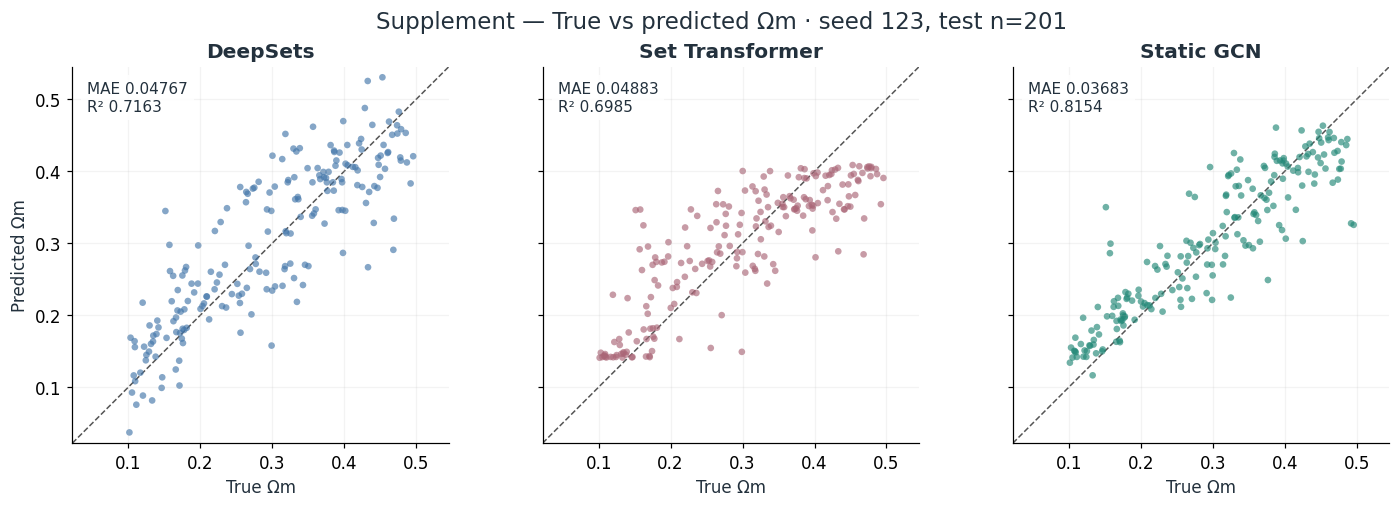

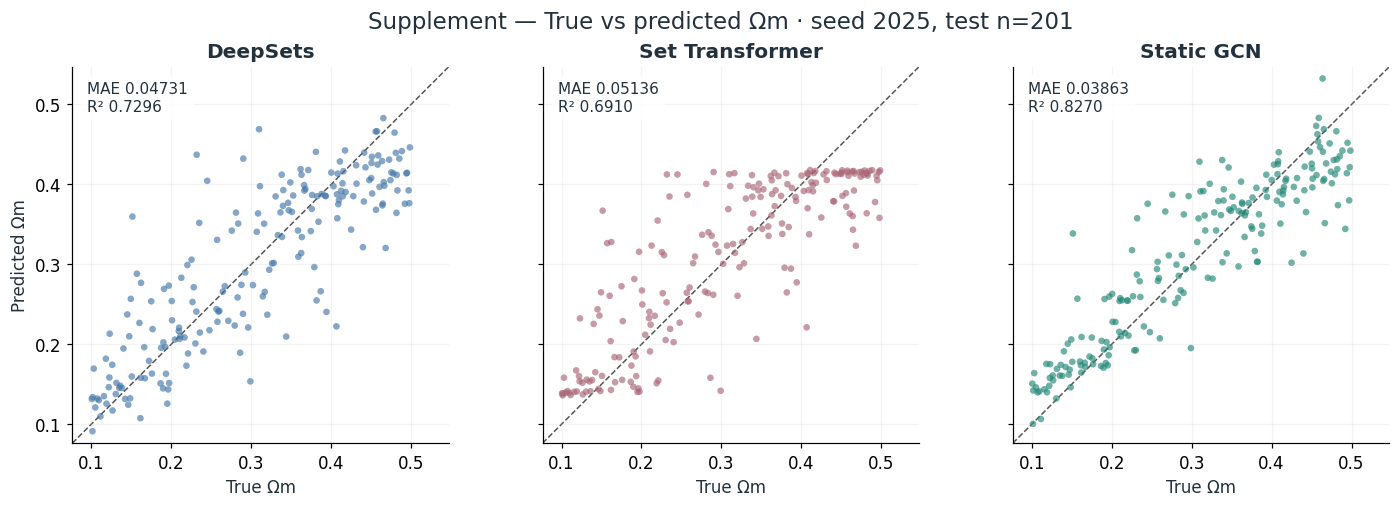

In [15]:
for seed in [123,2025]:
    prediction_panels(seed, f'figS0{2 if seed==123 else 3}_true_vs_predicted_seed{seed}',
                      f'Supplement — True vs predicted Ωm · seed {seed}, test n=201')

## Saved Set Transformer convergence
The saved logs provide comparable training and validation MSE trajectories. The best epoch is taken from the saved metrics and cross-checked against the strict minimum validation-MSE epoch. These curves assess whether there is an obvious catastrophic failed run; they cannot by themselves diagnose underfitting or identify why the representation underperforms.

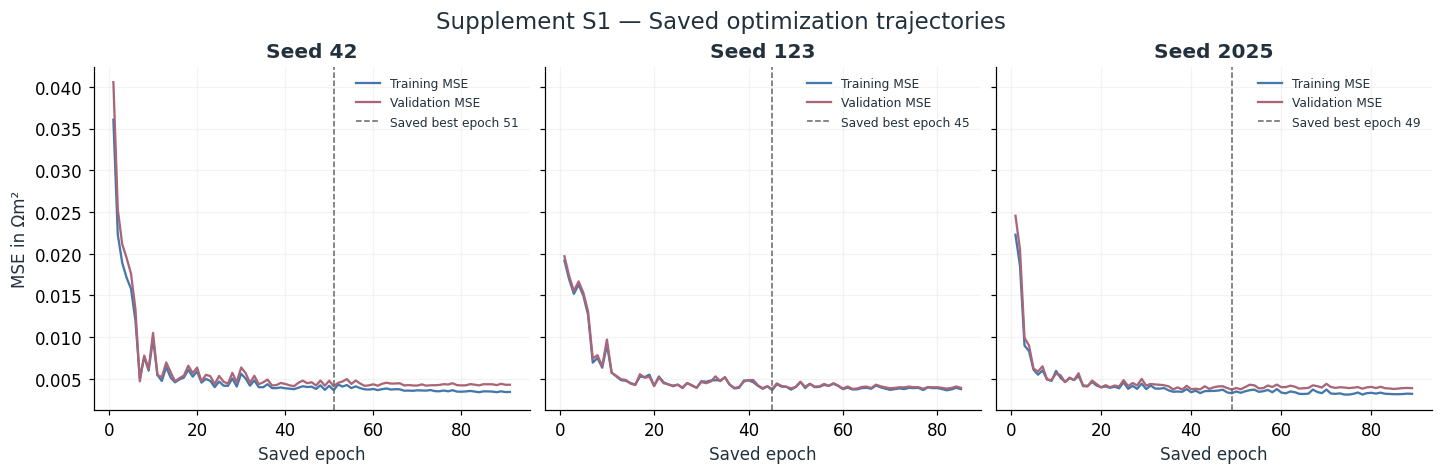

seed,epochs_logged,best_epoch,best_validation_mse
42,91,51,0.004116
123,85,45,0.003787
2025,89,49,0.003716


All three saved trajectories are finite and reach their recorded validation minima. This is consistent with completed optimization runs; it does not establish global convergence or rule out architecture-specific optimization limitations.

In [16]:
fig, axes = plt.subplots(1,3,figsize=(13,4.2),sharey=True,layout='constrained')
log_summary = []
for ax, seed in zip(axes,SEEDS):
    log = read_csv(ROOT / run_paths['Set Transformer',seed] / 'train_log.csv')
    assert log.epoch.is_unique and np.array_equal(log.epoch.to_numpy(), np.arange(1,len(log)+1))
    assert np.isfinite(log[['train_mse','validation_mse']].to_numpy()).all()
    best = run_metrics['Set Transformer',seed]['best_epoch']
    assert best == int(log.loc[log.validation_mse.idxmin(),'epoch'])
    ax.plot(log.epoch,log.train_mse,color='#4477AA',label='Training MSE')
    ax.plot(log.epoch,log.validation_mse,color='#AA6677',label='Validation MSE')
    ax.axvline(best,color='#666666',ls='--',lw=1,label=f'Saved best epoch {best}')
    ax.set(title=f'Seed {seed}',xlabel='Saved epoch'); ax.grid(alpha=.15); ax.legend(fontsize=8,frameon=False)
    log_summary.append({'seed':seed,'epochs_logged':len(log),'best_epoch':best,'best_validation_mse':log.validation_mse.min()})
axes[0].set_ylabel('MSE in Ωm²')
fig.suptitle('Supplement S1 — Saved optimization trajectories',fontsize=15)
savefig(fig,'figS01_set_transformer_training_convergence')
display(pd.DataFrame(log_summary).style.hide(axis='index'))
display(Markdown('All three saved trajectories are finite and reach their recorded validation minima. This is consistent with completed optimization runs; it does not establish global convergence or rule out architecture-specific optimization limitations.'))

# Appendix B. Complete Metrics / Diagnostic Tables
CSV tables retain full numeric precision. All diagnostic SDs are sample SDs; the all-seed metrics remain seed-level records. Bias and range statistics are descriptive, never used to refit or select models.

In [17]:
table(diagnostic_aggregate, 'table08_prediction_diagnostics_aggregate.csv', show=False)
table(binned, 'table09_residual_bin_statistics.csv', show=False)
table(all_seed, 'table10_all_models_per_seed_metrics.csv', show=False)
table(integrity, 'table11_metric_integrity.csv', show=False)
table(paired_summary.reset_index(), 'table12_paired_mae_summary.csv')
for title, frame in [('Full prediction diagnostics',diagnostics), ('Aggregate prediction diagnostics',diagnostic_aggregate),
                     ('All-model per-seed metrics',all_seed), ('Residual bin counts and means',binned)]:
    display(HTML(f'<details><summary>{title}</summary>{frame.to_html(index=False, float_format=lambda x: f"{x:.9f}")}</details>'))

comparison,mean,sd
Set Transformer − DeepSets,0.001717,0.002105
Set Transformer − Static GCN,0.011881,0.000909


model,seed,mae,mse,rmse,r2,median_absolute_error,p90_absolute_error,max_absolute_error,bias,residual_sd,true_mean,true_std,true_min,true_max,predicted_mean,predicted_std,predicted_min,predicted_max,spread_ratio,intercept,slope
DeepSets,42,0.049170672,0.003797233,0.061621690,0.740958889,0.038344234,0.098825246,0.163032666,-0.002758041,0.061713645,0.308619900,0.121375851,0.101000004,0.499399990,0.305861859,0.102416887,0.062825754,0.470418274,0.843799538,0.081576131,0.726737736
DeepSets,123,0.047666212,0.003695031,0.060786769,0.716251222,0.036970094,0.102886319,0.193327904,0.007469998,0.060476661,0.295308458,0.114399754,0.101400003,0.495799989,0.302778456,0.109271449,0.037036330,0.530548632,0.955172068,0.061675348,0.816444980
DeepSets,2025,0.047314990,0.003918707,0.062599579,0.729572041,0.033668637,0.104420602,0.208342105,-0.005222169,0.062537136,0.305581095,0.120678150,0.100599997,0.498600006,0.300358926,0.105473830,0.091209963,0.482886881,0.874009336,0.071884143,0.747673161
Set Transformer,42,0.049112603,0.003724772,0.061030911,0.745902033,0.042974815,0.092560709,0.177496359,-0.008194045,0.060629348,0.308619900,0.121375851,0.101000004,0.499399990,0.300425856,0.095597572,0.148262411,0.431318104,0.787616085,0.088894462,0.685410737
Set Transformer,123,0.048834171,0.003926225,0.062659593,0.698497431,0.036880299,0.100927755,0.194584399,0.000115418,0.062815940,0.295308458,0.114399754,0.101400003,0.495799989,0.295423876,0.085886428,0.140806466,0.408630252,0.750757103,0.109064353,0.631067341
Set Transformer,2025,0.051357242,0.004477932,0.066917354,0.690980211,0.038111992,0.116752326,0.215720326,0.000975359,0.067077312,0.305581095,0.120678150,0.100599997,0.498600006,0.306556454,0.099786796,0.136124983,0.417869985,0.826883702,0.096502680,0.687391259
Static GCN,42,0.038196001,0.002396302,0.048952042,0.836528100,0.029133111,0.080710948,0.141725034,-0.002104625,0.049028893,0.308619900,0.121375851,0.101000004,0.499399990,0.306515276,0.112007788,0.085115552,0.502534807,0.922817736,0.045974831,0.844211421
Static GCN,123,0.036829304,0.002403503,0.049025534,0.815430237,0.030931965,0.072820425,0.198639899,0.005027450,0.048888842,0.295308458,0.114399754,0.101400003,0.495799989,0.300335908,0.096504275,0.116372347,0.463295937,0.843570655,0.074575158,0.764491312
Static GCN,2025,0.038634553,0.002506766,0.050067615,0.827009374,0.031207889,0.078727990,0.187193304,0.003543753,0.050066744,0.305581095,0.120678150,0.100599997,0.498600006,0.309124848,0.102132089,0.100432098,0.532501101,0.846317984,0.073196359,0.772065069


model,mae_mean,mae_sd,mse_mean,mse_sd,rmse_mean,rmse_sd,r2_mean,r2_sd,median_absolute_error_mean,median_absolute_error_sd,p90_absolute_error_mean,p90_absolute_error_sd,max_absolute_error_mean,max_absolute_error_sd,bias_mean,bias_sd,residual_sd_mean,residual_sd_sd,true_mean_mean,true_mean_sd,true_std_mean,true_std_sd,true_min_mean,true_min_sd,true_max_mean,true_max_sd,predicted_mean_mean,predicted_mean_sd,predicted_std_mean,predicted_std_sd,predicted_min_mean,predicted_min_sd,predicted_max_mean,predicted_max_sd,spread_ratio_mean,spread_ratio_sd,intercept_mean,intercept_sd,slope_mean,slope_sd
DeepSets,0.048050625,0.000985758,0.003803657,0.000111976,0.061669346,0.000907344,0.728927384,0.012366442,0.036327655,0.002403091,0.102044056,0.002891204,0.188234225,0.023080197,-0.000170071,0.006730228,0.061575814,0.001037129,0.303169818,0.006975623,0.118817918,0.003842113,0.101000001,0.000400003,0.497933328,0.001890330,0.302999747,0.002758132,0.105720722,0.003433944,0.063690682,0.027097172,0.494617929,0.031735282,0.890993647,0.057596095,0.071711874,0.009951510,0.763618626,0.046931235
Set Transformer,0.049768005,0.001383342,0.004042976,0.000389918,0.063535953,0.003039500,0.711793225,0.029777260,0.039322369,0.003222505,0.103413597,0.012285892,0.195933695,0.019147672,-0.002367756,0.005064001,0.063507533,0.003279144,0.303169818,0.006975623,0.118817918,0.003842113,0.101000001,0.000400003,0.497933328,0.001890330,0.300802062,0.005575816,0.093756932,0.007130640,0.141731287,0.006121336,0.419272780,0.011408792,0.788418963,0.038069650,0.098153832,0.010185816,0.667956446,0.031962246
Static GCN,0.037886619,0.000941551,0.002435524,0.000061803,0.049348397,0.000623944,0.826322570,0.010565686,0.030424322,0.001126700,0.077419788,0.004104709,0.175852746,0.030104513,0.002155526,0.003763244,0.049328160,0.000643455,0.303169818,0.006975623,0.118817918,0.003842113,0.101000001,0.000400003,0.497933328,0.001890330,0.305325344,0.004513681,0.103548051,0.007848149,0.100639999,0.015629435,0.499443948,0.034705962,0.870902125,0.044981217,0.064582116,0.016129121,0.793589267,0.044003321


model,seed,best_epoch,val_mae,val_mse,val_rmse,val_r2,test_mae,test_mse,test_rmse,test_r2
Mean baseline,42,N/A,0.101068831,0.012906318,0.113605977,-0.020485699,0.105754953,0.014822202,0.121746466,-0.011146810
Mean baseline,123,N/A,0.101545206,0.013551157,0.116409435,-0.000312855,0.099040424,0.013053740,0.114252964,-0.002422568
Mean baseline,2025,N/A,0.104057869,0.014070863,0.118620668,-0.002163188,0.106098156,0.014549560,0.120621556,-0.004057585
Ridge,42,N/A,0.025727997,0.000994047,0.031528506,0.921402027,0.023721165,0.000936584,0.030603653,0.936107771
Ridge,123,N/A,0.021420907,0.000728881,0.026997792,0.946195825,0.024523249,0.000895181,0.029919581,0.931257251
Ridge,2025,N/A,0.025362399,0.001026578,0.032040259,0.926884451,0.023665376,0.000912301,0.030204314,0.937042607
Random Forest,42,N/A,0.010606147,0.000181562,0.013474481,0.985644159,0.008894146,0.000142350,0.011931055,0.990289106
Random Forest,123,N/A,0.009124792,0.000139083,0.011793360,0.989733211,0.009279228,0.000148187,0.012173190,0.988620461
Random Forest,2025,N/A,0.009030010,0.000149543,0.012228785,0.989349148,0.009953909,0.000174176,0.013197585,0.987980187
Gradient Boosting,42,N/A,0.008736071,0.000135796,0.011653133,0.989262826,0.008949248,0.000146196,0.012091136,0.990026772


model,seed,bin,left,right,count,true_mean,residual_mean
DeepSets,42,0,0.100000000,0.180000000,44,0.138227273,0.024976562
DeepSets,42,1,0.180000000,0.260000000,27,0.216125925,0.045003589
DeepSets,42,2,0.260000000,0.340000000,42,0.304523811,0.010474647
DeepSets,42,3,0.340000000,0.420000000,40,0.378609999,-0.009691319
DeepSets,42,4,0.420000000,0.500000000,48,0.462100000,-0.060848216
DeepSets,123,0,0.100000000,0.180000000,49,0.144600000,0.024920424
DeepSets,123,1,0.180000000,0.260000000,30,0.219893334,0.025259543
DeepSets,123,2,0.260000000,0.340000000,45,0.303382221,0.020102928
DeepSets,123,3,0.340000000,0.420000000,41,0.381390244,-0.000321299
DeepSets,123,4,0.420000000,0.500000000,36,0.455155558,-0.038024332


# Appendix C. Reproducibility Closure
The closure rehashes every source consumed during execution, including all manifest-listed checkpoints, predictions, metrics and existing Notebooks 1–16. The source manifest records checkout-relative paths. Only Notebook-17 tables, figures and closure reports are written.

Raster exports use 240 dpi and a self-contained white figure canvas for legibility in light or dark notebook themes; no global notebook theme is overridden. PNGs are decoded and checked for plausible dimensions and nonblank content; PDFs must be nonempty and have a PDF signature; all exported tables must parse with finite numeric columns. The generated-file inventory excludes its own hash to avoid a circular checksum.

In [18]:
assert len([p for p in GENERATED if p.suffix=='.png' and p.name.startswith('fig0')]) == 9
assert len(GENERATED) == len(set(GENERATED))
for path, expected in SOURCES.items():
    assert sha(ROOT / path) == expected, f'Source changed: {path}'
source_table = pd.DataFrame([{'path':p,'sha256':h,'size_bytes':(ROOT/p).stat().st_size} for p,h in sorted(SOURCES.items())])
table(source_table,'source_artifact_manifest.csv',show=False)
repro = {'verdict':'PASS', 'creation_head':CREATION_HEAD, 'execution_head':HEAD,
         'protocol_sha256':PROTOCOL_HASH, 'seeds':SEEDS, 'canonical_visualization_seed':CANONICAL_SEED,
         'ddof':DDOF, 'metric_atol':TOL, 'metric_rtol':0,
         'max_metric_disagreement':float(integrity.absolute_disagreement.max()),
         'prediction_files_checked':117, 'source_files_rehashed':len(SOURCES),
         'training_run':False, 'inference_run':False, 'checkpoint_deserialized':False,
         'selection_modified':False, 'source_artifacts_modified':False,
         'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'matplotlib':matplotlib.__version__}}
p = OUT/'reproducibility_closure.json'; p.write_text(json.dumps(repro,indent=2)+'\n'); GENERATED.append(p)
p = OUT/'scientific_conclusion.md'; p.write_text(conclusion+'\n'); GENERATED.append(p)
assets=[]
for p in sorted(GENERATED):
    assert p.parent.resolve() == OUT.resolve() and p.stat().st_size > 0
    dimensions = 'N/A'
    if p.suffix == '.png':
        with Image.open(p) as image:
            image.load(); w,h = image.size
            assert 500 <= w <= 6000 and 400 <= h <= 6000 and w*h < 30000000
            assert np.asarray(image.convert('RGB')).std() > 5
            dimensions=f'{w} × {h}'
    elif p.suffix == '.pdf':
        assert p.read_bytes().startswith(b'%PDF-') and p.stat().st_size > 1000
    elif p.suffix == '.csv':
        frame = pd.read_csv(p,keep_default_na=False)
        assert len(frame) > 0 and np.isfinite(frame.select_dtypes(include='number').to_numpy()).all()
    assets.append({'filename':p.name,'size_bytes':p.stat().st_size,'dimensions':dimensions,'sha256':sha(p)})
asset_table=pd.DataFrame(assets)
asset_table.to_csv(OUT/'generated_asset_manifest.csv',index=False)
display(asset_table[['filename','size_bytes','dimensions']].style.hide(axis='index'))
display(HTML('<details><summary>Complete source artifact paths and hashes</summary>'+source_table.to_html(index=False)+'</details>'))
print(f'PASS — {len(asset_table)} assets plus generated_asset_manifest.csv; all source hashes unchanged.')

filename,size_bytes,dimensions
fig01_controlled_mae_comparison.pdf,24795,N/A
fig01_controlled_mae_comparison.png,138848,2907 × 1351
fig02_paired_test_mae_differences.pdf,17726,N/A
fig02_paired_test_mae_differences.png,109286,2427 × 1266
fig03_true_vs_predicted_seed42.pdf,34450,N/A
fig03_true_vs_predicted_seed42.png,323387,3007 × 1107
fig04_sorted_predictions_seed42.pdf,35182,N/A
fig04_sorted_predictions_seed42.png,361406,2907 × 1947
fig05_residual_structure_seed42.pdf,33198,N/A
fig05_residual_structure_seed42.png,310614,3147 × 1131


path,sha256,size_bytes
configs/experiment_families/u1000_top1500_set_transformer.json,153e01395fe4da0492db57d0e7c5009bd656ee99bb6162ef94180eb34d125efe,3298
configs/splits/u1000_top1000_none_k8_sparse/seed123_train700.json,2e2d1043dd2c0517ab0084a0d31f09f3af7875a8bcb341c4a7362c6c419e04c4,29554
configs/splits/u1000_top1000_none_k8_sparse/seed2025_train700.json,e80a9ce994257b2ce818c10e452d4d4a0ba3ec7cacc80cc199480677e38f4c72,29553
configs/splits/u1000_top1000_none_k8_sparse/seed42_train700.json,b56f35e4cbf1307344beaaf5b26cf181004d23d04fd719b678f1edb9e9924571,29631
configs/splits/u1000_top1500_none_k8_sparse/seed123_train700.json,18a295106ec844848053f3040d2be3cdf73a443010be31e6e2cd962362982471,29745
configs/splits/u1000_top1500_none_k8_sparse/seed2025_train700.json,c233c0631b1a24d963ffccc7c6389054fddf135a7aabc4dc4ab7bf5976fab3a9,29744
configs/splits/u1000_top1500_none_k8_sparse/seed42_train700.json,f5556ec5c193e7cb80f2231705edbdae32d4de206889dec308a819bdde427ab7,29822
experiments/deepsets_u1000_top1500_raw7_final_train700_seed123_none_h32_phi3_mean_statichead/checkpoints/best_model.pt,965f66864d6089625d20b85b25e8c147410655d3cecb36d6784e13e49b1afaf0,22882
experiments/deepsets_u1000_top1500_raw7_final_train700_seed123_none_h32_phi3_mean_statichead/config.json,3ffa0093ecbf5bae9d1ba72a27f86ea5ae43e5e62950a5c8b6bcde831b6acec6,2452
experiments/deepsets_u1000_top1500_raw7_final_train700_seed123_none_h32_phi3_mean_statichead/metrics.json,915f96603797ea4a71c9469e12c9a452b03ff5db49f5a682110b9b4953e0e0f1,583


PASS — 39 assets plus generated_asset_manifest.csv; all source hashes unchanged.
